# TA-RecMind V2 — Intra-Layer Gated Fusion

Kiến trúc cập nhật theo phân tích toàn diện: intra-layer gated fusion, gate đối xứng user-item, negative sampling 3-thành-phần, stratified evaluation.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0: CÀI ĐẶT & BIẾN MÔI TRƯỜNG
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:256"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

!pip install -q sentence-transformers huggingface_hub datasets

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: IMPORTS & CẤU HÌNH TRUNG TÂM
# ═══════════════════════════════════════════════════════════════════════════════
import gc, json, time, threading, subprocess, psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# ── Mount Google Drive ──────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
    print("[INFO] Google Drive mounted.")
except ImportError:
    IN_COLAB = False
    print("[WARN] Không có môi trường Colab. Chạy local.")

_DRIVE_ROOT = "/content/drive/MyDrive/tarecmind"

CFG = {
    "REPO_ID":   "chuongdo1104/amazon-2023-gold",
    "SILVER_REPO_ID": "chuongdo1104/amazon-2023-silver",
    "DRIVE_ROOT": _DRIVE_ROOT,
    "DATA_DIR":   f"{_DRIVE_ROOT}/data",
    "SAVE_DIR":   f"{_DRIVE_ROOT}/weights",
    "CACHE_DIR":  "/content/recsys_cache",

    # Model
    "EMBED_DIM":   128,
    "LLM_DIM":     384,
    "GCN_LAYERS":  2,
    "TEMPERATURE": 0.2,

    # Training
    "EPOCHS":          100,
    "LR_JOINT":        1e-3,
    "WEIGHT_DECAY":    1e-4,
    "GRAD_CLIP":       1.0,

    # Loss weights — V2: tăng lambda_align, giảm noise_scale
    "LAMBDA_ALIGN":   0.3,
    "LAMBDA_CL":      0.005,
    "NOISE_SCALE":    0.08,
    #"LAMBDA_TEMPORAL": 0.5,   # decay Electronics: nhẹ hơn V1

    # Evaluation
    "PATIENCE":        10,
    "EVAL_EVERY":      2,      # eval mỗi 2 epoch để tiết kiệm thời gian
    #"EVAL_STRAT_N":    8000,   # TĂNG TỪ 1000 LÊN 4000 để đánh giá ổn định hơn

    # Encoding LLM
    "ENCODE_CHUNK":  30000,
    "ENCODE_BATCH":  256,

    "SAVE_EVERY_EPOCH": True,
    "KEEPALIVE_MINS":   25,

    "EVAL_STRAT_GROUPS": {
        "HEAD": 2500,
        "MID":  2500,
        "TAIL": 2500,
        "COLD": 2500,
    },
}

for d in [CFG["DATA_DIR"], CFG["SAVE_DIR"], CFG["CACHE_DIR"]]:
    os.makedirs(d, exist_ok=True)

print("[INFO] Cấu hình V2 đã sẵn sàng.")

Mounted at /content/drive
[INFO] Google Drive mounted.
[INFO] Cấu hình V2 đã sẵn sàng.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: PHÁT HIỆN GPU & ĐIỀU CHỈNH BATCH SIZE
# ═══════════════════════════════════════════════════════════════════════════════
def detect_and_adjust_gpu():
    sys_ram_gb = psutil.virtual_memory().total / 1e9
    print(f"[INFO] System RAM: {sys_ram_gb:.1f} GB")

    if not torch.cuda.is_available():
        print("[WARN] Không có GPU.")
        return "cpu"

    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"[INFO] GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB")

    # Sửa lại logic dựa vào VRAM thay vì string name để tránh nhầm lẫn A100 40GB/80GB
    if vram_gb > 70:
        # Chế độ A100 80GB
        CFG["BATCH_SIZE"]     = 32768
        CFG["ALIGN_SUBBATCH"] = 8192
        CFG["ACCUM_STEPS"]    = 1
        CFG["ENCODE_BATCH"]   = 1024
        print(f"   → Chế độ VRAM > 70GB: batch={CFG['BATCH_SIZE']}, subbatch={CFG['ALIGN_SUBBATCH']}")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    elif vram_gb > 35:
        # Chế độ A100 40GB (Tăng 2x BATCH_SIZE so với trước)
        CFG["BATCH_SIZE"]     = 16384
        CFG["ALIGN_SUBBATCH"] = 4096
        CFG["ACCUM_STEPS"]    = 2
        CFG["ENCODE_BATCH"]   = 512
        print(f"   → Chế độ VRAM > 35GB (A100 40G): batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    elif vram_gb > 16:
        # Chế độ V100/L4 24GB
        CFG["BATCH_SIZE"]     = 4096
        CFG["ALIGN_SUBBATCH"] = 1024
        CFG["ACCUM_STEPS"]    = 4
        CFG["ENCODE_BATCH"]   = 512
        print(f"   → Chế độ VRAM > 16GB: batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")
    else:
        # Chế độ T4 16GB
        CFG["BATCH_SIZE"]     = 2048
        CFG["ALIGN_SUBBATCH"] = 512
        CFG["ACCUM_STEPS"]    = 4
        CFG["ENCODE_BATCH"]   = 256
        print(f"   → Chế độ T4 (<16GB): batch={CFG['BATCH_SIZE']}, accum={CFG['ACCUM_STEPS']}")

    return "cuda"

device = detect_and_adjust_gpu()

# ── Keep-alive thread ──────────────────────────────────────────────────────────────────────────────
_keepalive_stop = threading.Event()
def _keepalive_worker():
    interval = CFG["KEEPALIVE_MINS"] * 60
    ka_file  = os.path.join(CFG["CACHE_DIR"], "keepalive.txt")
    while not _keepalive_stop.is_set():
        time.sleep(interval)
        if not _keepalive_stop.is_set():
            with open(ka_file, "w") as f:
                f.write(f"alive {time.strftime('%H:%M:%S')}\n")

threading.Thread(target=_keepalive_worker, daemon=True).start()
print(f"[INFO] Keep-alive thread started. Device: {device}")


[INFO] System RAM: 89.6 GB
[INFO] GPU: NVIDIA A100-SXM4-40GB | VRAM: 42.4 GB
   → Chế độ VRAM > 35GB (A100 40G): batch=16384, accum=2
[INFO] Keep-alive thread started. Device: cuda


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: TẢI DỮ LIỆU & THÔNG TIN GRAPH
# Cập nhật theo pipeline thực tế (gold_step1, gold_step2, gold_step5)
# Artifacts: gold_dataset_stats.json, gold_edge_index.npy,
#            gold_item_train_freq.npy, gold_item_popularity_group.npy,
#            gold_user_train_freq.npy,  gold_user_activity_group.npy,
#            gold_negative_sampling_prob.npy
# ═══════════════════════════════════════════════════════════════════════════════

# ── Popularity / Activity group codes (phải khớp gold_step5_training_meta.py) ─
POP_GROUP  = {0: "HEAD", 1: "MID", 2: "TAIL", 3: "COLD_START"}
USER_GROUP = {0: "INACTIVE", 1: "ACTIVE", 2: "SUPER_ACTIVE"}

def download_hf(filename, local_dir=None):
    target     = local_dir or CFG["CACHE_DIR"]
    local_path = os.path.join(target, os.path.basename(filename))
    if os.path.exists(local_path):
        return local_path
    print(f"[INFO] Đang tải {filename}...")
    return hf_hub_download(
        repo_id=CFG["REPO_ID"], filename=filename,
        repo_type="dataset", local_dir=target,
    )

# ── 1. Dataset stats (n_users, n_items, sparsity …) ──────────────────────────
print("\n--- TẢI METADATA ---")
with open(download_hf("gold/gold_dataset_stats.json"), "r") as f:
    dataset_stats = json.load(f)

num_users   = dataset_stats["n_users"]
num_items   = dataset_stats["n_items"]
total_nodes = num_users + num_items
print(f"[INFO] {num_users:,} users | {num_items:,} items | {total_nodes:,} nodes tổng")
print(f"[INFO] Sparsity: {dataset_stats.get('sparsity_pct','N/A')} | "
      f"Avg degree user: {dataset_stats.get('avg_degree_user','N/A')}")

# ── 2. Edge index [2, E] ──────────────────────────────────────────────────────
edge_index_raw = np.load(download_hf("gold/gold_edge_index.npy"))
train_edge_index = torch.from_numpy(edge_index_raw).long()
n_train_edges    = train_edge_index.shape[1]
del edge_index_raw

# ── 3. Item frequency & popularity group ─────────────────────────────────────
item_train_freq_np    = np.load(download_hf("gold/gold_item_train_freq.npy"))          # int64
item_pop_group_np     = np.load(download_hf("gold/gold_item_popularity_group.npy"))    # int8: 0=HEAD,1=MID,2=TAIL,3=COLD
item_train_freq_t     = torch.from_numpy(item_train_freq_np).long()
item_pop_group_t      = torch.from_numpy(item_pop_group_np.astype("int32")).long()

# ── 4. User frequency & activity group ───────────────────────────────────────
user_train_freq_np    = np.load(download_hf("gold/gold_user_train_freq.npy"))          # int64
user_activity_group_np = np.load(download_hf("gold/gold_user_activity_group.npy"))    # int8: 0=INACTIVE,1=ACTIVE,2=SUPER_ACTIVE
user_train_freq_t      = torch.from_numpy(user_train_freq_np).long()
user_activity_group_t  = torch.from_numpy(user_activity_group_np.astype("int32")).long()

# ── 5. Negative sampling prob (đã normalize + clip sẵn trong pipeline) ───────
neg_prob_np = np.load(download_hf("gold/gold_negative_sampling_prob.npy"))   # float32, sum≈1
neg_prob_t  = torch.from_numpy(neg_prob_np).float()
# KHÔNG cần normalize lại — pipeline đã làm trong gold_step5_training_meta.py

# ── 6. Tail edge indices (oversampling trong training loop) ───────────────────
# TAIL = group code 2 (theo POP_GROUP_MAP trong gold_step5)
# Ngưỡng freq <= 5 tương ứng định nghĩa TAIL; dùng pop_group trực tiếp để nhất quán
tail_item_mask    = (item_pop_group_t == 2)                    # TAIL items (group code 2)
is_tail_edge      = tail_item_mask[train_edge_index[1]]        # item node ở hàng 1 của edge_index
tail_edge_indices = torch.where(is_tail_edge)[0]

# ── 7. Sanity checks ──────────────────────────────────────────────────────────
assert n_train_edges > 0,               "Edge list rỗng!"
assert len(item_train_freq_np) == num_items, \
    f"item_freq length {len(item_train_freq_np)} != num_items {num_items}"
assert len(user_train_freq_np) == num_users, \
    f"user_freq length {len(user_train_freq_np)} != num_users {num_users}"
assert len(neg_prob_np) == num_items,   "neg_prob length != num_items"
assert abs(neg_prob_np.sum() - 1.0) < 5e-4, "neg_prob không sum to 1"

# ── 8. Log phân phối popularity / activity ───────────────────────────────────
print(f"\n[INFO] {n_train_edges:,} edges | {int(tail_edge_indices.shape[0]):,} tail edges")
print("[INFO] Item popularity distribution:")
for code, name in POP_GROUP.items():
    cnt = int((item_pop_group_t == code).sum())
    print(f"  {name:10s}: {cnt:,} ({cnt/num_items*100:.1f}%)")
print("[INFO] User activity distribution:")
for code, name in USER_GROUP.items():
    cnt = int((user_activity_group_t == code).sum())
    print(f"  {name:12s}: {cnt:,} ({cnt/num_users*100:.1f}%)")
print(f"\n[SUCCESS] Dữ liệu graph đã sẵn sàng.")

# ── 9. Giải phóng bộ nhớ numpy (giữ lại tensor) ──────────────────────────────
del item_train_freq_np, item_pop_group_np
del user_train_freq_np, user_activity_group_np
del neg_prob_np
gc.collect()



--- TẢI METADATA ---
[INFO] Đang tải gold/gold_dataset_stats.json...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


gold_dataset_stats.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

[INFO] 1,847,662 users | 1,610,012 items | 3,457,674 nodes tổng
[INFO] Sparsity: 99.9995% | Avg degree user: 7.56
[INFO] Đang tải gold/gold_edge_index.npy...


gold/gold_edge_index.npy:   0%|          | 0.00/223M [00:00<?, ?B/s]

...

gold/gold_user_activity_group.npy:   0%|          | 0.00/1.85M [00:00<?, ?B/s]

[INFO] Đang tải gold/gold_negative_sampling_prob.npy...


gold/gold_negative_sampling_prob.npy:   0%|          | 0.00/6.44M [00:00<?, ?B/s]


[INFO] 13,964,281 edges | 1,212,254 tail edges
[INFO] Item popularity distribution:
  HEAD      : 210,925 (13.1%)
  MID       : 116,283 (7.2%)
  TAIL      : 714,913 (44.4%)
  COLD_START: 567,891 (35.3%)
[INFO] User activity distribution:
  INACTIVE    : 827,127 (44.8%)
  ACTIVE      : 927,738 (50.2%)
  SUPER_ACTIVE: 92,797 (5.0%)

[SUCCESS] Dữ liệu graph đã sẵn sàng.


149

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: LLM EMBEDDINGS — DRIVE-BACKED CACHE (chunk-by-chunk, chống OOM)
# Cập nhật theo pipeline thực tế:
#   - silver_item_text_profile.parquet  → col "item_text" (partitioned by popularity_group)
#   - silver_user_text_profile.parquet  → col "user_text"
#   - gold_item_id_map.parquet          → col "parent_asin", "item_idx"
#   - gold_user_id_map.parquet          → col "reviewer_id", "user_idx"
# ═══════════════════════════════════════════════════════════════════════════════

FORCE_ENCODE = False   # True → encode lại từ đầu dù cache đã tồn tại

# ── Đường dẫn helper ─────────────────────────────────────────────────────────
def drive_path_emb(prefix):
    return os.path.join(CFG["DATA_DIR"], f"gold_{prefix}_embeddings.npy")

def local_path_emb(prefix):
    return os.path.join(CFG["CACHE_DIR"], f"gold_{prefix}_embeddings.npy")

def ckpt_path(prefix, i, end):
    return os.path.join(CFG["DATA_DIR"], f"ckpt_{prefix}_{i}_{end}.npy")

# ── Kiểm tra xem có cần encode không ─────────────────────────────────────────
need_item_emb = FORCE_ENCODE or not os.path.exists(drive_path_emb("item"))
need_user_emb = FORCE_ENCODE or not os.path.exists(drive_path_emb("user"))

if need_item_emb or need_user_emb:
    gc.collect(); torch.cuda.empty_cache()

    print(f"[INFO] Khởi tạo SentenceTransformer (all-MiniLM-L6-v2) trên {device}...")
    model_st = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    if device == "cuda":
        model_st = model_st.half()   # FP16 tiết kiệm VRAM

    # ── Hàm encode chunk-by-chunk với checkpoint Drive ───────────────────────
    def encode_and_save(texts: list, prefix: str) -> None:
        """
        Encode texts thành embeddings (float32, L2-normalized).
        Lưu từng chunk lên Drive → an toàn khi Colab bị ngắt.
        """
        total_len = len(texts)
        parts = []
        for i in range(0, total_len, CFG["ENCODE_CHUNK"]):
            end  = min(i + CFG["ENCODE_CHUNK"], total_len)
            ckpt = ckpt_path(prefix, i, end)
            if os.path.exists(ckpt) and not FORCE_ENCODE:
                print(f"  [SKIP] {prefix} chunk {i:,}-{end:,} (cache tồn tại).")
                parts.append(np.load(ckpt))
            else:
                print(f"  [ENCODE] {prefix} chunk {i:,}-{end:,} ...")
                chunk_emb = model_st.encode(
                    texts[i:end],
                    batch_size=CFG["ENCODE_BATCH"],
                    show_progress_bar=True,
                    normalize_embeddings=True,   # L2-norm → cosine sim = dot product
                    convert_to_numpy=True,
                )
                np.save(ckpt, chunk_emb)
                parts.append(chunk_emb)
                gc.collect()

        final = np.vstack(parts).astype(np.float32)
        np.save(drive_path_emb(prefix), final)
        print(f"[SUCCESS] Đã encode & lưu {prefix} embeddings → Drive. Shape: {final.shape}")

    # ── ITEM EMBEDDINGS ───────────────────────────────────────────────────────
    if need_item_emb:
        print("\n--- ENCODING ITEM EMBEDDINGS ---")

        # Đọc gold_item_id_map (lấy thứ tự item_idx chuẩn)
        df_item_map = pd.read_parquet(
            download_hf("gold/gold_item_id_map.parquet", local_dir=CFG["CACHE_DIR"])
        )
        df_item_map["parent_asin"] = df_item_map["parent_asin"].astype(str).str.strip()

        # Đọc silver_item_text_profile (partitioned by popularity_group → phải load toàn folder)
        # Dùng HF datasets API với split="train"; pipeline ghi parquet zstd có partition columns
        df_item_silver = load_dataset(
            CFG["SILVER_REPO_ID"],                           # vd: "chuongdo1104/amazon-2023-silver"
            data_dir="silver/silver_item_text_profile.parquet",
            split="train",
        ).to_pandas()
        df_item_silver["parent_asin"] = df_item_silver["parent_asin"].astype(str).str.strip()

        # Merge theo item_idx thứ tự (phải sort sau merge để đảm bảo thứ tự đúng)
        item_merged = df_item_map[["parent_asin", "item_idx"]].merge(
            df_item_silver[["parent_asin", "item_text"]],
            on="parent_asin", how="left",
        )

        # Kiểm tra chất lượng merge
        empty_cnt = item_merged["item_text"].isna().sum()
        if empty_cnt > 0.10 * len(item_merged):
            print(f"[WARN] {empty_cnt:,} / {len(item_merged):,} items không match được item_text "
                  f"({empty_cnt/len(item_merged)*100:.1f}%) — kiểm tra lại SILVER_REPO_ID!")
        else:
            print(f"[OK] Merge item_text thành công: {len(item_merged) - empty_cnt:,} có text, "
                  f"{empty_cnt:,} fallback rỗng.")

        # Sort theo item_idx đảm bảo embedding[i] ↔ item i trong train_edge_index
        item_texts = (
            item_merged.sort_values("item_idx")["item_text"]
            .fillna("[NO_TEXT] Item description")          # cold-start items → placeholder
            .tolist()
        )
        assert len(item_texts) == num_items, \
            f"item_texts length {len(item_texts)} != num_items {num_items}"

        del df_item_map, df_item_silver, item_merged
        gc.collect()

        encode_and_save(item_texts, "item")
        del item_texts
        gc.collect()

    # ── USER EMBEDDINGS ───────────────────────────────────────────────────────
    if need_user_emb:
        print("\n--- ENCODING USER EMBEDDINGS ---")

        # Đọc gold_user_id_map
        df_user_map = pd.read_parquet(
            download_hf("gold/gold_user_id_map.parquet", local_dir=CFG["CACHE_DIR"])
        )
        df_user_map["reviewer_id"] = df_user_map["reviewer_id"].astype(str).str.strip()

        # Đọc silver_user_text_profile
        df_user_silver = load_dataset(
            CFG["SILVER_REPO_ID"],
            data_dir="silver/silver_user_text_profile.parquet",
            split="train",
        ).to_pandas()
        df_user_silver["reviewer_id"] = df_user_silver["reviewer_id"].astype(str).str.strip()

        # Merge + sort theo user_idx
        user_merged = df_user_map[["reviewer_id", "user_idx"]].merge(
            df_user_silver[["reviewer_id", "user_text"]],
            on="reviewer_id", how="left",
        )

        empty_cnt_u = user_merged["user_text"].isna().sum()
        if empty_cnt_u > 0.10 * len(user_merged):
            print(f"[WARN] {empty_cnt_u:,} users không có user_text!")
        else:
            print(f"[OK] Merge user_text thành công.")

        user_texts = (
            user_merged.sort_values("user_idx")["user_text"]
            .fillna("[NO_TEXT] User interaction profile")  # fallback khớp silver_step3
            .tolist()
        )
        assert len(user_texts) == num_users, \
            f"user_texts length {len(user_texts)} != num_users {num_users}"

        del df_user_map, df_user_silver, user_merged
        gc.collect()

        encode_and_save(user_texts, "user")
        del user_texts
        gc.collect()

    del model_st
    gc.collect(); torch.cuda.empty_cache()
    print("\n[INFO] Hoàn tất encoding.")

else:
    print("[INFO] LLM Embeddings đã có trên Drive — bỏ qua bước encode.")

# ── Copy embeddings Drive → local SSD (tăng tốc I/O khi training) ────────────
print("\n[INFO] Copy embeddings Drive → SSD local...")
for prefix in ["item", "user"]:
    local_p = local_path_emb(prefix)
    drive_p = drive_path_emb(prefix)
    if not os.path.exists(local_p):
        # shutil.copy2 hoạt động trên mọi OS (Windows + Colab/Linux)
        import shutil
        shutil.copy2(drive_p, local_p)
        print(f"  [COPIED] {prefix}: {drive_p} → {local_p}")
    else:
        print(f"  [SKIP] {prefix} đã tồn tại trên SSD local.")

# ── Load embeddings vào RAM ───────────────────────────────────────────────────
item_emb_llm = torch.from_numpy(np.load(local_path_emb("item"))).float()
user_emb_llm = torch.from_numpy(np.load(local_path_emb("user"))).float()

# Sanity check shape
assert item_emb_llm.shape == (num_items, CFG.get("LLM_DIM", 384)), \
    f"item_emb_llm shape {item_emb_llm.shape} không khớp!"
assert user_emb_llm.shape == (num_users, CFG.get("LLM_DIM", 384)), \
    f"user_emb_llm shape {user_emb_llm.shape} không khớp!"

print(f"\n[READY] LLM Embeddings loaded:")
print(f"  Item: {item_emb_llm.shape} | dtype: {item_emb_llm.dtype}")
print(f"  User: {user_emb_llm.shape} | dtype: {user_emb_llm.dtype}")


[INFO] LLM Embeddings đã có trên Drive — bỏ qua bước encode.

[INFO] Copy embeddings Drive → SSD local...
  [COPIED] item: /content/drive/MyDrive/tarecmind/data/gold_item_embeddings.npy → /content/recsys_cache/gold_item_embeddings.npy
  [COPIED] user: /content/drive/MyDrive/tarecmind/data/gold_user_embeddings.npy → /content/recsys_cache/gold_user_embeddings.npy

[READY] LLM Embeddings loaded:
  Item: torch.Size([1610012, 384]) | dtype: torch.float32
  User: torch.Size([1847662, 384]) | dtype: torch.float32


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: XỬ LÝ GRAPH — SPARSE ADJACENCY MATRIX & VAL EDGES
# ═══════════════════════════════════════════════════════════════════════════════

path_train_edges  = os.path.join(CFG["DATA_DIR"], "train_edges.pt")
path_val_edges    = os.path.join(CFG["DATA_DIR"], "val_edges.pt")
path_val_meta     = os.path.join(CFG["DATA_DIR"], "val_meta.pt")
path_sparse_adj   = os.path.join(CFG["DATA_DIR"], "sparse_adj.pt")

# ── BƯỚC 1: Val edges từ silver_val_ground_truth ─────────────────────────────
if all(os.path.exists(p) for p in [path_val_edges, path_val_meta]):
    print("[INFO] Tải val_edges từ Drive cache...")
    val_edges_t    = torch.load(path_val_edges, map_location="cpu", weights_only=True)
    val_meta_t     = torch.load(path_val_meta,  map_location="cpu", weights_only=True)
    VAL_SIZE       = val_edges_t.shape[1]
    print(f"  [OK] val_edges: {VAL_SIZE:,}")
else:
    print("[INFO] Build val_edges từ silver_val_ground_truth.parquet...")

    # 1. Tải dataset từ Silver Repo (Partitioned Parquet)
    df_val_gt = load_dataset(
        CFG["SILVER_REPO_ID"],
        data_dir="silver/silver_val_ground_truth.parquet",
        split="train",
    ).to_pandas()
    print(f"  [OK] Loaded {len(df_val_gt):,} val rows từ silver repo.")

    # 2. Đảm bảo tải Gold ID Maps để ánh xạ ID String -> Integer Index
    # FIX: Tự động tải nếu thiếu để tránh FileNotFoundError
    path_item_map = download_hf("gold/gold_item_id_map.parquet")
    path_user_map = download_hf("gold/gold_user_id_map.parquet")

    df_item_map = pd.read_parquet(path_item_map, columns=["parent_asin", "item_idx"])
    df_user_map = pd.read_parquet(path_user_map, columns=["reviewer_id", "user_idx"])

    # 3. Inner Join để ánh xạ
    df_val_gt = (
        df_val_gt
        .merge(df_item_map, on="parent_asin", how="inner")
        .merge(df_user_map, on="reviewer_id", how="inner")
    )

    VAL_SIZE    = len(df_val_gt)
    val_edges_t = torch.tensor(
        np.stack([df_val_gt["user_idx"].values.astype(np.int64),
                  df_val_gt["item_idx"].values.astype(np.int64)], axis=0),
        dtype=torch.long,
    )

    # Lưu metadata (is_tail, is_cold) để đánh giá phân tầng
    val_meta_t = {
        "is_tail": torch.tensor(df_val_gt["is_tail"].values.astype(np.uint8), dtype=torch.uint8),
        "is_cold_start": torch.tensor(df_val_gt["is_cold_start"].values.astype(np.uint8), dtype=torch.uint8),
    }

    torch.save(val_edges_t, path_val_edges)
    torch.save(val_meta_t,  path_val_meta)
    print(f"  [OK] Đã build & lưu val_edges: {VAL_SIZE:,} pairs.")
    del df_val_gt, df_item_map, df_user_map; gc.collect()

# ── BƯỚC 2: train_edge_index ─────────────────────────────────────────────────
if os.path.exists(path_train_edges):
    print("[INFO] Tải train_edges từ Drive cache...")
    train_edge_index = torch.load(path_train_edges, map_location=device, weights_only=True)
else:
    # train_edge_index lấy từ gold_edge_index.npy đã tải ở Cell 3
    train_edge_index = train_edge_index.to(device)
    torch.save(train_edge_index.cpu(), path_train_edges)

n_train_edges = train_edge_index.shape[1]

# ── BƯỚC 3: Sparse Adjacency Matrix (float16 CSR) ───────────────────────────
if os.path.exists(path_sparse_adj):
    print("[INFO] Tải sparse_adj từ Drive cache...")
    sparse_adj = torch.load(path_sparse_adj, map_location=device, weights_only=True)
else:
    print("[INFO] Xây dựng sparse_adj (Bipartite User-Item)...")
    # Biến đổi sang đồ thị đối xứng: user (0..num_users-1), item (num_users..total_nodes-1)
    row = torch.cat([train_edge_index[0], train_edge_index[1] + num_users])
    col = torch.cat([train_edge_index[1] + num_users, train_edge_index[0]])
    gei = torch.stack([row, col]).long()

    # Chuẩn hóa bậc: D^-1/2 * A * D^-1/2
    deg = torch.bincount(gei[0], minlength=total_nodes).float()
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    ew = (deg_inv_sqrt[gei[0]] * deg_inv_sqrt[gei[1]]).half() # fp16 tiết kiệm 50% RAM

    adj = torch.sparse_coo_tensor(gei, ew, (total_nodes, total_nodes))
    sparse_adj = adj.coalesce().to(device).to_sparse_csr()

    torch.save(sparse_adj.cpu(), path_sparse_adj)
    del adj, ew, deg, deg_inv_sqrt, gei, row, col; gc.collect()

# ── BƯỚC 4: Đồng bộ hóa dữ liệu lên Device ──────────────────────────────────
print("[INFO] Đưa các tensor phụ trợ lên GPU...")
item_train_freq_t   = item_train_freq_t.to(device)
user_train_freq_t   = user_train_freq_t.to(device)
item_pop_group_t    = item_pop_group_t.to(device)
neg_prob_t          = neg_prob_t.to(device)

# Lấy index của các cạnh thuộc nhóm TAIL (để phục vụ tail-oversampling)
tail_item_mask    = (item_pop_group_t == 2)
is_tail_edge      = tail_item_mask[train_edge_index[1]]
tail_edge_indices = torch.where(is_tail_edge)[0]

# Normalize LLM Embeddings ngay lập tức (thực hiện ở fp32 để tránh underflow trước khi cast sang fp16)
item_emb_llm = F.normalize(item_emb_llm.to(device), p=2, dim=1).half()
user_emb_llm = F.normalize(user_emb_llm.to(device), p=2, dim=1).half()

print(f"\n[SUCCESS] Graph sẵn sàng.")
print(f"  Train: {n_train_edges:,} | Val: {VAL_SIZE:,}")
print(f"  Tail edges: {len(tail_edge_indices):,} ({len(tail_edge_indices)/n_train_edges*100:.1f}%)")
print(f"  sparse_adj: float16 CSR on {device}")
gc.collect(); torch.cuda.empty_cache()


[INFO] Tải val_edges từ Drive cache...
  [OK] val_edges: 1,847,662
[INFO] Tải train_edges từ Drive cache...
[INFO] Tải sparse_adj từ Drive cache...
[INFO] Đưa các tensor phụ trợ lên GPU...

[SUCCESS] Graph sẵn sàng.
  Train: 13,964,281 | Val: 1,847,662
  Tail edges: 1,212,254 (8.7%)
  sparse_adj: float16 CSR on cuda


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: KIẰN TRÐC TARecMind V2 — INTRA-LAYER GATED FUSION
#
# Cập nhật theo pipeline:
#   • freq_all: cat([user_train_freq_t, item_train_freq_t]).float()  ← int64 từ Cell 3/5
#   • z_llm_all: cat([user_emb_llm, item_emb_llm])                  ← float16 trân GPU
#                → project_text() → float32 trước khi dùng trong GCN
#   • niche_ratio_all: tính từ train_edge_index + item_pop_group_t   ← mới, pipeline-backed
#   • adj dtype: float16 (sparse_adj từ Cell 5)
#   • In-place slice fix: gate_logit[:N_u] → tách tensor tránh autograd lỗi
# ═══════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
import torch
import torch.nn as nn
import gc

# ── PRE-COMPUTE: freq_all [N_total] và niche_ratio_all [N_total] ─────────────
# Được tính 1 lần ở đây, truyền vào model mỗi forward để tránh recompute.

# freq_all: ghép user_freq || item_freq → [N_total], float32
# (user_train_freq_t + item_train_freq_t là int64 từ Cell 3; cần cast float để log1p)
freq_all = torch.cat([
    user_train_freq_t.float(),   # [N_users]  — số lần user xuất hiện trong train
    item_train_freq_t.float(),   # [N_items]  — số lần item xuất hiện trong train
]).to(device)                    # [N_total]

# niche_ratio_all: tỉ lệ TAIL/COLD items trong lịch sử tương tác của mỗi user
# Phần user: = #{tail/cold edges của user} / #{tổng edges của user}
# Phần item: = 0.0 (không áp dụng)
# Dùng item_pop_group_t (group 2=TAIL, 3=COLD) + train_edge_index từ Cell 3/5
_is_tail_or_cold = ((item_pop_group_t == 2) | (item_pop_group_t == 3)).float()  # [N_items]
_edge_is_niche   = _is_tail_or_cold[train_edge_index[1]]                         # [E]

# Đếm per-user bằng scatter_add (không cần loop Python)
_user_niche_cnt  = torch.zeros(num_users, device=device)
_user_total_cnt  = torch.zeros(num_users, device=device)
_user_idx_edge   = train_edge_index[0]                                            # [E] user idx
_user_niche_cnt.scatter_add_(0, _user_idx_edge, _edge_is_niche.to(device))
_user_total_cnt.scatter_add_(0, _user_idx_edge,
                              torch.ones(train_edge_index.shape[1], device=device))
_user_niche_ratio = _user_niche_cnt / (_user_total_cnt + 1e-8)                   # [N_users]

# Ghép: [N_users niche_ratio || N_items zeros] → [N_total]
niche_ratio_all = torch.cat([
    _user_niche_ratio,
    torch.zeros(num_items, device=device),
])
del _is_tail_or_cold, _edge_is_niche, _user_niche_cnt, _user_total_cnt
del _user_idx_edge, _user_niche_ratio
gc.collect()

print(f"[INFO] freq_all      : {freq_all.shape}, dtype={freq_all.dtype}")
print(f"[INFO] niche_ratio_all: {niche_ratio_all.shape}, "
      f"user niche mean={niche_ratio_all[:num_users].mean():.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# MODEL CLASS
# ═══════════════════════════════════════════════════════════════════════════════
class TARecMindV2(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=128, llm_dim=384, gcn_layers=2):
        super().__init__()
        self.num_users  = num_users
        self.num_items  = num_items
        self.embed_dim  = embed_dim
        self.gcn_layers = gcn_layers

        # ID embeddings (Collaborative Filtering signal)
        self.user_id_emb = nn.Embedding(num_users, embed_dim)
        self.item_id_emb = nn.Embedding(num_items, embed_dim)
        nn.init.normal_(self.user_id_emb.weight, std=0.01) # Cập nhật std=0.01
        nn.init.normal_(self.item_id_emb.weight, std=0.01) # Cập nhật std=0.01

        # Text projection: llm_dim (384) → embed_dim
        # Input: float16 từ SentenceTransformer → output: float32
        self.text_prj = nn.Linear(llm_dim, embed_dim)

        # Gate MLP: concat [E_graph || z_LLM] → scalar logit
        # Phi tuyến: học tương tác giữa 2 nguồn thay vì cộng tuyến tính (V1)
        self.gate_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1),
        )
        # Khởi tạo nhỏ → gate gần sigmoid(0)=0.5 khi bắt đầu train
        for m in self.gate_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.001)
                nn.init.zeros_(m.bias)

        # Scalar learnable signals
        self.w_freq  = nn.Parameter(torch.tensor(0.5))   # tín hiệu tần suất
        self.w_sim   = nn.Parameter(torch.tensor(0.5))   # tín hiệu cosine similarity
        self.w_niche = nn.Parameter(torch.tensor(0.3))   # giảm gamma user niche

        # Alpha global: kết hợp z_G (GCN) và z_L (LLM) ở output
        self.alpha = nn.Parameter(torch.tensor(0.5))

    # ── Gate γ^(l) — đối xứng user-item ─────────────────────────────────────
    def _compute_gate(self, x_graph, z_llm, freq_all, niche_ratio_all, chunk_size=500_000):
        N = x_graph.size(0)
        gamma_chunks = []
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)
            x_chunk = x_graph[start:end]
            z_chunk = z_llm[start:end]
            freq_chunk = freq_all[start:end]
            niche_chunk = niche_ratio_all[start:end]

            # MLP
            gate_input = torch.cat([x_chunk, z_chunk], dim=1)
            base = self.gate_mlp(gate_input)

            # Frequency signal
            freq_signal = torch.log1p(freq_chunk).unsqueeze(1) * self.w_freq

            # Cosine similarity signal
            cos_sim = F.cosine_similarity(x_chunk, z_chunk, dim=1, eps=1e-8).unsqueeze(1)
            cos_signal = cos_sim * self.w_sim

            gate_logit = base + freq_signal + cos_signal

            # Niche signal (chỉ áp dụng cho user nodes)
            # Phần user (0..N_u-1), item không có niche
            # Ta cần biết vị trí bắt đầu của user/item trong chunk
            # → dùng mask: nếu start < N_u thì chunk có thể chứa user
            N_u = self.num_users
            if start < N_u:
                user_end = min(end, N_u)
                user_mask = torch.zeros(end - start, 1, device=x_graph.device)
                user_mask[:user_end - start] = 1.0
                niche_adj = niche_chunk.unsqueeze(1) * self.w_niche * user_mask
            else:
                niche_adj = torch.zeros(end - start, 1, device=x_graph.device)

            gate_logit = gate_logit - niche_adj

            gamma = torch.sigmoid(gate_logit)

            # Cold mask: ép gamma về 0.0 cho các item cold (freq == 0)
            cold_mask = (freq_chunk == 0).unsqueeze(1)
            gamma = torch.where(cold_mask, torch.tensor(0.0, device=gamma.device, dtype=gamma.dtype), gamma)

            gamma_chunks.append(gamma)
            # Giải phóng bộ nhớ rõ ràng (không cần thiết trong Python nhưng giúp)
            del gate_input, base, freq_signal, cos_sim, cos_signal, gate_logit, x_chunk, z_chunk
        return torch.cat(gamma_chunks, dim=0)

    # ── Intra-layer gated GCN forward — V2 core ──────────────────────────────
    def forward_gcn_gated(
        self,
        adj: torch.Tensor,               # sparse CSR [N_total, N_total] float16
        z_llm_all: torch.Tensor,         # [N_total, d] float32 (đã project)
        freq_all: torch.Tensor,          # [N_total]    float32
        niche_ratio_all: torch.Tensor,   # [N_total]    float32
    ) -> torch.Tensor:
        """
        Intra-layer gated fusion (RecMind Eq.6-8):
          Ê^(l) = γ^(l)·E^(l) + (1-γ^(l))·z_LLM   ← gate tính TRƯỘC nhân adj
          E^(l+1) = Â · Ê^(l)                        ← LightGCN propagation
        γ được tính lại mỗi tầng vì E^(l) thay đổi.
        Layer-average: z_G = mean(E^(0), ..., E^(L))
        """
        # E^(0): base ID embedding, float32
        x = torch.cat([
            self.user_id_emb.weight,   # [N_users, d]
            self.item_id_emb.weight,   # [N_items, d]
        ], dim=0)                      # [N_total, d]

        # Accumulator cho đầu ra để tránh stack tất cả các layer tốn VRAM
        z_G_accum = x.clone()

        for _ in range(self.gcn_layers):
            # 1. Tính gate tại tầng này (dùng E^(l) hiện tại)
            gamma = self._compute_gate(x, z_llm_all, freq_all, niche_ratio_all)

            # 2. Intra-layer fusion: Ê^(l) = γ·x + (1-γ)·z_llm
            # Dùng torch.lerp thay vì addcmul để tránh tạo tensor x - z_llm_all
            x_fused = torch.lerp(z_llm_all, x, gamma)   # [N, d] float32

            # 3. LightGCN propagation
            # adj là float16 → cast x_fused xuống fp16, nhân, cast lại fp32
            x = torch.sparse.mm(adj, x_fused.to(adj.dtype)).to(torch.float32)
            z_G_accum += x

        # Layer-averaged output (LightGCN Eq.2)
        z_G = z_G_accum / (self.gcn_layers + 1.0)   # [N_total, d]
        return z_G

    # ── Text projection ───────────────────────────────────────────────────────────────────────
    def project_text(self, llm_emb: torch.Tensor) -> torch.Tensor:
        """llm_emb: [B, llm_dim] float16 hoặc float32 → [B, embed_dim] float32."""
        return self.text_prj(llm_emb.float())   # đảm bảo float32 cho Linear

    # ── Final representation (RecMind Eq.9) ─────────────────────────────────────────────
    def get_final_repr(self, z_G: torch.Tensor, z_L: torch.Tensor) -> torch.Tensor:
        alpha = torch.sigmoid(self.alpha)
        return alpha * z_G + (1.0 - alpha) * z_L

    # ── Forward pass ────────────────────────────────────────────────────────────
    def forward(
        self,
        adj,                  # sparse CSR [N_total, N_total] float16
        z_llm_all,            # [N_total, d] float32 — đã project, cache ngoài forward
        freq_all,             # [N_total]    float32 — cat([user_freq, item_freq])
        niche_ratio_all,      # [N_total]    float32 — cat([user_niche, item_zeros])
        batch_users,          # [B]          long
        batch_pos,            # [B]          long
        batch_neg,            # [B]          long
        u_llm,                # [B, llm_dim] float16 — raw LLM batch (chưa project)
        pos_llm,              # [B, llm_dim] float16
        neg_llm,              # [B, llm_dim] float16
    ):
        """
        z_llm_all: đã project (text_prj đã áp dụng) — dùng cho GCN
        u/pos/neg_llm: raw LLM batch — project tại đây cho z_L
        """
        # ── GCN với intra-layer gated fusion
        z_G_all = self.forward_gcn_gated(adj, z_llm_all, freq_all, niche_ratio_all)
        user_G_all, item_G_all = z_G_all.split([self.num_users, self.num_items])

        # Lấy embedding theo batch idx
        u_G   = user_G_all[batch_users]   # [B, d]
        pos_G = item_G_all[batch_pos]     # [B, d]
        neg_G = item_G_all[batch_neg]     # [B, d]

        # Project raw LLM batch → z_L
        u_L   = self.project_text(u_llm)    # [B, d]
        pos_L = self.project_text(pos_llm)  # [B, d]
        neg_L = self.project_text(neg_llm)  # [B, d]

        # Final repr = α·z_G + (1-α)·z_L
        final_u   = self.get_final_repr(u_G,   u_L)
        final_pos = self.get_final_repr(pos_G, pos_L)
        final_neg = self.get_final_repr(neg_G, neg_L)

        # Trả thêm (u_G, u_L, pos_G, pos_L, neg_G, neg_L) cho alignment loss trong training loop
        return final_u, final_pos, final_neg, u_G, u_L, pos_G, pos_L, neg_G, neg_L


print("[INFO] TARecMindV2 class đã định nghĩa.")
print(f"[INFO] freq_all ready: {freq_all.shape} | niche_ratio_all: {niche_ratio_all.shape}")


[INFO] freq_all      : torch.Size([3457674]), dtype=torch.float32
[INFO] niche_ratio_all: torch.Size([3457674]), user niche mean=0.088
[INFO] TARecMindV2 class đã định nghĩa.
[INFO] freq_all ready: torch.Size([3457674]) | niche_ratio_all: torch.Size([3457674])


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: HÀM MẤT MÁT
#
# Cập nhật theo pipeline:
#   • freq tensors từ Cell 3/5: dtype int64 → phải cast .float() trước khi log
#   • lagcl_noise: sửa docstring (tail items nhận NHIỀU noise hơn, không phải ít)
#   • tail_weighted_alignment_loss: chuẩn hóa ổn định hơn (/ w.sum())
#
# Tham số từ gold_step5_training_meta.py:
#   negative_sampling_beta      = 0.75  (đã baked vào neg_prob_t)
#   neg_sampling_blend_alpha    = 0.70  (đã baked vào neg_prob_t)
#   → Các loss functions không cần biết beta/alpha; neg_prob_t đã sẵn sàng.
# ═══════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F   # đảm bảo F luôn đúng namespace trong cell này


# ── 1. Adaptive Margin BPR Loss ────────────────────────────────────────────────
def bpr_loss(
    user_emb: torch.Tensor,   # [B, d] float32
    pos_emb:  torch.Tensor,   # [B, d] float32
    neg_emb:  torch.Tensor,   # [B, d] float32
    pos_freq: torch.Tensor = None, # [B] int64 hoặc float32 (tuỳ chọn)
    margin_scale: float = 0.1,     # Hệ số scale margin
) -> torch.Tensor:
    """
    Bayesian Personalized Ranking loss kết hợp Adaptive Margin.
    Giả định embeddings CHƯA L2-normalize (normalize trong loss để kiểm soát tốt hơn).
    """
    # L2-normalize trong loss để tính cosine score
    u  = F.normalize(user_emb, p=2, dim=1)
    pi = F.normalize(pos_emb,  p=2, dim=1)
    ni = F.normalize(neg_emb,  p=2, dim=1)

    pos_scores = (u * pi).sum(dim=1)     # [B]
    neg_scores = (u * ni).sum(dim=1)     # [B]

    if pos_freq is not None:
        # Tail item (freq nhỏ) -> margin lớn, Head item -> margin nhỏ
        freq_f = pos_freq.float()
        margin = margin_scale / torch.log(freq_f + 2.0)
    else:
        margin = 0.0

    return -F.logsigmoid(pos_scores - neg_scores - margin).mean()


# ── 2. LAGCL Noise Augmentation ───────────────────────────────────────────────
def lagcl_noise(
    embeddings: torch.Tensor,    # [B, d] float32
    item_freq:  torch.Tensor,    # [B]    int64 hoặc float32
    noise_scale: float = 0.08,
) -> torch.Tensor:
    """
    LAGCL: Frequency-Adaptive Gaussian noise augmentation.

    Công thức: noise_weight = noise_scale / log(freq + 2)
      - HEAD items (freq lớn): log lớn → noise_weight NHỎ → augmentation nhẹ
      - TAIL/COLD items (freq nhỏ): log nhỏ → noise_weight LỐN → augmentation mạnh

    Mục tiâu: tăng cường đa dạng biểu diễn tail items để cải thiện recall@K.
    Tương thích: item_freq có thể là int64 (từ item_train_freq_t) hoặc float32.
    """
    # FIX: cast float để log hoạt động đúng với int64 input từ pipeline
    freq_f       = item_freq.float()
    noise_weight = noise_scale / torch.log(freq_f + 2.0)   # [B], luôn > 0
    return embeddings + torch.randn_like(embeddings) * noise_weight.unsqueeze(1)


# ── 3. Contrastive Loss (LAGCL InfoNCE) ───────────────────────────────────────
def contrastive_loss_lagcl(
    v1: torch.Tensor,          # [B, d] float32 — view 1 (augmented)
    v2: torch.Tensor,          # [B, d] float32 — view 2 (augmented)
    temperature: float = 0.15,
    subbatch: int = None,      # Thâm subbatch để chống OOM ma trận [B, B]
) -> torch.Tensor:
    """
    InfoNCE / NT-Xent loss giữa 2 augmented views của cùng batch.
    Dùng trong LAGCL để kéo gần 2 stochastic views của cùng node.

    temperature=0.15: giá trị nhỏ → phân biệt sắc nét hơn, phù hợp sparse recsys.
    Áp dụng chunking (subbatching) để tránh OOM khi B đạt hàng chục ngàn.
    """
    if subbatch is None:
        subbatch = CFG.get("ALIGN_SUBBATCH", 512)

    v1 = F.normalize(v1, p=2, dim=1)
    v2 = F.normalize(v2, p=2, dim=1)
    B = v1.size(0)

    total_loss = 0.0
    labels_full = torch.arange(B, device=v1.device)

    for start in range(0, B, subbatch):
        end = min(start + subbatch, B)
        # sim_chunk: [subbatch, B]
        sim_chunk = torch.mm(v1[start:end], v2.t()) / temperature
        loss_chunk = F.cross_entropy(sim_chunk, labels_full[start:end], reduction="sum")
        total_loss += loss_chunk

    return total_loss / B


# ── 4. Contrastive Alignment Loss (Eq.5 Symmetric InfoNCE) ────────────────────
# Phương án thay thế (chuẩn bài báo) – không dùng trong giai đoạn này.
# def contrastive_alignment_loss(z_graph: torch.Tensor, z_text: torch.Tensor, temperature: float = 0.2) -> torch.Tensor:
#     """
#     Symmetric InfoNCE giữa z_graph và z_text.
#     z_graph, z_text: [B, d] đã được L2‑normalize.
#     """
#     B = z_graph.size(0)
#     # Tính similarity matrix
#     sim_g2t = torch.mm(z_graph, z_text.t()) / temperature   # [B, B]
#     sim_t2g = sim_g2t.t()
#
#     labels = torch.arange(B, device=z_graph.device)
#     loss_g2t = F.cross_entropy(sim_g2t, labels)
#     loss_t2g = F.cross_entropy(sim_t2g, labels)
#     return (loss_g2t + loss_t2g) / 2.0


# ── 5. Tail-Weighted Alignment Loss ───────────────────────────────────────────
def tail_weighted_alignment_loss(
    z_graph:     torch.Tensor,   # [N, d] float32 — GCN output (batch hoặc full)
    z_text:      torch.Tensor,   # [N, d] float32 — LLM projection output
    freq:        torch.Tensor,   # [N]    int64 hoặc float32 — item/user frequency
    temperature: float = 0.15,
    subbatch:    int   = None,
) -> torch.Tensor:
    """
    InfoNCE alignment loss với trọng số tail (Optional, có thể thay bằng contrastive_alignment_loss):
      w(i) = 1 / log(1 + freq(i) + ε)    → tail/cold items: w lớn (ưu tiân căn chỉnh)

    Sub-batch để tránh OOM khi N lớn.

    Chuẩn hóa:
      loss = Σ_i w(i) · ce(i) / Σ_i w(i)   ← weighted mean (ổn định hơn / N·w.mean())

    Tương thích: freq có thể là int64 từ pipeline.
    """
    if subbatch is None:
        subbatch = CFG.get("ALIGN_SUBBATCH", 512)

    z_g = F.normalize(z_graph, p=2, dim=1)
    z_t = F.normalize(z_text,  p=2, dim=1)
    N   = z_g.size(0)

    # FIX: cast float → đảm bảo log hoạt động đúng với int64
    freq_f  = freq.float()
    w       = 1.0 / torch.log(1.0 + freq_f + 1e-8)   # [N], dương

    labels_full = torch.arange(N, device=z_g.device)
    weighted_sum = torch.tensor(0.0, device=z_g.device)
    w_sum        = w.sum()

    for start in range(0, N, subbatch):
        end       = min(start + subbatch, N)
        sim_chunk = torch.mm(z_g[start:end], z_t.t()) / temperature   # [sub, N]
        ce_chunk  = F.cross_entropy(
            sim_chunk, labels_full[start:end], reduction="none"
        )                                                               # [sub]
        weighted_sum = weighted_sum + (w[start:end] * ce_chunk).sum()

    # FIX: / w_sum thay vì / (N * w.mean() + 1e-8) → giống nhau về giá trị
    return weighted_sum / (w_sum + 1e-8)


# ── Kiểm tra nhanh với tensor giả ─────────────────────────────────────────────
if __name__ == "__main__" or True:   # luôn chạy trong notebook
    _B, _d = 32, 128
    _dummy_u   = torch.randn(_B, _d)
    _dummy_pos = torch.randn(_B, _d)
    _dummy_neg = torch.randn(_B, _d)
    _freq_int  = torch.randint(0, 200, (_B,))   # int64, giống pipeline

    _l_bpr   = bpr_loss(_dummy_u, _dummy_pos, _dummy_neg, _freq_int)
    _noised  = lagcl_noise(_dummy_pos, _freq_int)
    _l_ctr   = contrastive_loss_lagcl(_dummy_pos, _noised)
   # _l_align_sym = contrastive_alignment_loss(F.normalize(_dummy_u, p=2, dim=1), F.normalize(_dummy_pos, p=2, dim=1))
    _l_align = tail_weighted_alignment_loss(_dummy_u, _dummy_pos, _freq_int, subbatch=16)

    print(f"[OK] bpr_loss   = {_l_bpr.item():.4f}")
    print(f"[OK] lagcl_noise shape = {_noised.shape}")
    print(f"[OK] contrastive_loss  = {_l_ctr.item():.4f}")
    #print(f"[OK] sym_align_loss    = {_l_align_sym.item():.4f}")
    print(f"[OK] tail_align_loss   = {_l_align.item():.4f}")
    del _dummy_u, _dummy_pos, _dummy_neg, _freq_int, _noised

print("[INFO] Các hàm loss đã định nghĩa và kiểm tra OK.")


[OK] bpr_loss   = 0.7111
[OK] lagcl_noise shape = torch.Size([32, 128])
[OK] contrastive_loss  = 0.0471
[OK] tail_align_loss   = 3.6454
[INFO] Các hàm loss đã định nghĩa và kiểm tra OK.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: NEGATIVE SAMPLING 3-THÀNH-PHẦN (CÓ LỌC FALSE NEGATIVE)
#
# ── PHÂN TÍCH neg_prob_t TỪ PIPELINE (gold_step5_training_meta.py) ───────────
# neg_prob_t = blended strategy đã tính sẵn:
#   P(j) = 0.70 · freq^{-0.75}  +  0.30 · freq^{+0.30}
#   → xác suất CAO = TAIL/COLD items (chiếm 70% tín hiệu)
#   → xác suất THẤP = HEAD items (giữ lại 30% để model học phân biệt head)
#
# ── CHIẾN LƯỢC 3 THÀNH PHẦN (ĐÃ HIỆU CHỈNH) ─────────────────────────────────
# Thành phần 1 (30%): Uniform random         → đa dạng không thiên vị
# Thành phần 2 (50%): neg_prob_t (blended)   → tail-focus + head-retain từ pipeline
# Thành phần 3 (20%): Tail-edge oversampling → gradient trực tiếp từ tail edges
# ═══════════════════════════════════════════════════════════════════════════════
import torch

def sample_negatives_3component(
    batch_size:        int,
    num_items:         int,
    neg_prob_t:        torch.Tensor,    # [N_items] float32, sum≈1 — từ gold_step5
    tail_edge_indices: torch.Tensor,    # [E_tail]  long — edges có item là TAIL
    train_edge_index:  torch.Tensor,    # [2, E]    long — toàn bộ train edges
    device:            torch.device,
    u:                 torch.Tensor = None, # [batch_size] long — users trong batch
    user_train_dict:   dict = None          # dict mapping user -> set/tensor of interacted items
) -> torch.Tensor:
    """
    Negative sampling 3 thành phần, có cơ chế lọc False Negatives (nếu được cung cấp user_train_dict).
    """
    n2 = int(batch_size * 0.50)   # blended neg_prob_t (50%)
    n3 = int(batch_size * 0.20)   # tail oversampled (20%)
    n1 = batch_size - n2 - n3     # uniform phần còn lại (30%)

    def _sample():
        # ── Thành phần 1: Uniform
        neg1 = torch.randint(0, num_items, (n1,), device=device)
        # ── Thành phần 2: Blended tail+head
        neg2 = torch.multinomial(neg_prob_t, n2, replacement=True)
        # ── Thành phần 3: Tail-edge oversampling
        rand_edge_pos = torch.randint(0, len(tail_edge_indices), (n3,), device=device)
        tail_sampled_edges = tail_edge_indices[rand_edge_pos]
        neg3 = train_edge_index[1, tail_sampled_edges]
        return torch.cat([neg1, neg2, neg3])

    negatives = _sample()

    # ── Cơ chế lọc False Negatives (nếu có thông tin) ──
    if u is not None and user_train_dict is not None:
        max_retries = 3
        for _ in range(max_retries):
            # Xác định các vị trí bị trùng (false negatives)
            # Chuyển đổi qua CPU list để kiểm tra nhanh trong dict
            u_list = u.cpu().tolist()
            neg_list = negatives.cpu().tolist()

            conflict_mask = torch.zeros(batch_size, dtype=torch.bool, device=device)
            for i in range(batch_size):
                user_id = u_list[i]
                neg_id = neg_list[i]
                # Kiểm tra nếu neg_id nằm trong tập item user đã tương tác
                if user_id in user_train_dict and neg_id in user_train_dict[user_id]:
                    conflict_mask[i] = True

            num_conflicts = conflict_mask.sum().item()
            if num_conflicts == 0:
                break  # Không còn va chạm

            # Resample chỉ cho những vị trí bị va chạm
            resampled = torch.randint(0, num_items, (num_conflicts,), device=device)
            negatives[conflict_mask] = resampled

    return negatives


# ── Smoke test ─────────────────────────────────────────────────────────────────
_neg_sample = sample_negatives_3component(
    batch_size=256,
    num_items=num_items,
    neg_prob_t=neg_prob_t,
    tail_edge_indices=tail_edge_indices,
    train_edge_index=train_edge_index,
    device=device,
)
assert _neg_sample.shape == (256,), f"Shape sai: {_neg_sample.shape}"
assert _neg_sample.max() < num_items, "neg item idx vượt num_items!"
assert _neg_sample.min() >= 0,       "neg item idx âm!"
del _neg_sample

print("[INFO] Hàm negative sampling 3-thành-phần đã sẵn sàng (Hỗ trợ lọc False Negative).")
print(f"  Tỷ lệ: Uniform 30% | Blended (neg_prob_t) 50% | Tail-edge 20%")


[INFO] Hàm negative sampling 3-thành-phần đã sẵn sàng (Hỗ trợ lọc False Negative).
  Tỷ lệ: Uniform 30% | Blended (neg_prob_t) 50% | Tail-edge 20%


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 (HOÀN CHỈNH – TỐI ƯU VRAM): STRATIFIED EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
import torch

# Hàm update_llm_cache vẫn giữ nguyên
def update_llm_cache(model, user_emb_llm, item_emb_llm, device, chunk=16384):
    model.eval()
    parts = []
    with torch.no_grad():
        for emb_full in [user_emb_llm, item_emb_llm]:
            N = emb_full.shape[0]
            for s in range(0, N, chunk):
                e = min(s + chunk, N)
                parts.append(model.project_text(emb_full[s:e].to(device)).cpu())
    return torch.cat(parts, dim=0).to(device)


def build_stratified_eval_sample(val_edges_t, item_pop_group_t, cfg_groups, seed=42):
    """
    cfg_groups: dict {group_name_str: desired_count}
    group mapping: HEAD=0, MID=1, TAIL=2, COLD=3
    """
    torch.manual_seed(seed)

    val_u   = val_edges_t[0].cpu()
    val_i   = val_edges_t[1].cpu()
    pop_g   = item_pop_group_t.cpu()

    # Đếm số lượng mẫu thực tế của mỗi nhóm trong val
    val_i_groups = pop_g[val_i]
    group_counts = torch.bincount(val_i_groups, minlength=4)  # 0..3

    group_names = ["HEAD", "MID", "TAIL", "COLD"]

    def _sample_items(mask, k):
        """Trả về indices của những mẫu (cạnh) mà item thuộc nhóm mask."""
        idx = mask.nonzero(as_tuple=False).squeeze(1)
        if len(idx) == 0:
            return None
        k = min(k, len(idx))
        perm = torch.randperm(len(idx), generator=torch.Generator().manual_seed(seed))[:k]
        chosen = idx[perm]
        return chosen   # trả về chỉ số trong val_edges_t

    groups = {}
    for gname, desired in cfg_groups.items():
        gcode = group_names.index(gname)  # 0=HEAD, 1=MID, 2=TAIL, 3=COLD
        avail = group_counts[gcode].item()
        n_sample = min(desired, avail)   # không lấy quá số có thực
        if n_sample == 0:
            print(f"  [WARN] {gname}: không có mẫu nào trong val.")
            groups[gname] = None
            continue

        # Tạo mask cho các cạnh có item thuộc nhóm gcode
        mask = (val_i_groups == gcode)
        chosen_idx = _sample_items(mask, n_sample)

        groups[gname] = {
            "u": val_u[chosen_idx],
            "i": val_i[chosen_idx],
            "is_tail": (pop_g[val_i[chosen_idx]] == 2).to(torch.uint8),
            "is_cold": (pop_g[val_i[chosen_idx]] == 3).to(torch.uint8),
        }
        # Log nhẹ
        n_tail = groups[gname]["is_tail"].sum().item()
        n_cold = groups[gname]["is_cold"].sum().item()
        print(f"  [SAMPLE] {gname}: {n_sample:4d} mẫu (tail={n_tail}, cold={n_cold})")

    # Nếu một nhóm bị None (không có mẫu), thay bằng HEAD (fallback) – ít xảy ra.
    fallback = groups.get("HEAD")
    for gname in list(groups):
        if groups[gname] is None:
            print(f"  [WARN] {gname}: fallback sang HEAD.")
            groups[gname] = fallback

    return groups


def evaluate_stratified(
    model, adj, z_llm_all_cached, freq_all, niche_ratio_all,
    user_emb_llm, item_emb_llm, item_pop_group_t,
    eval_groups, num_users, num_items,
    K=20, device="cuda", user_chunk=64, item_chunk=32768,
    train_mask_dict=None
):
    """
    Full-ranking evaluation có phân tầng item (HEAD/MID/TAIL/COLD)
    + Coverage, TailCoverage, AvgPopularity.
    Nếu train_mask_dict được cung cấp, sẽ loại bỏ các item đã có trong tập train
    khỏi kết quả xếp hạng (training masking).
    """
    model.eval()
    pop_g = item_pop_group_t.to(device)   # 0=HEAD,1=MID,2=TAIL,3=COLD
    POP_NAMES = {0: "HEAD", 1: "MID", 2: "TAIL", 3: "COLD"}

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            # 1) Tính GCN toàn bộ đồ thị (z_G_all: [N_total, d])
            z_G_all = model.forward_gcn_gated(adj, z_llm_all_cached, freq_all, niche_ratio_all)

            # 2) Xây dựng item_final theo chunk (tiết kiệm VRAM)
            #    view item_G_all trực tiếp từ z_G_all mà không copy
            item_G_all = z_G_all[num_users:]
            item_final_chunks = []
            for s in range(0, num_items, item_chunk):
                e = min(s + item_chunk, num_items)
                # item_emb_llm đã ở GPU (fp16), project_text cast về float32
                item_L_chunk = model.project_text(item_emb_llm[s:e])
                chunk_final = model.get_final_repr(item_G_all[s:e], item_L_chunk)
                chunk_final = F.normalize(chunk_final, p=2, dim=1)
                item_final_chunks.append(chunk_final)
                del item_L_chunk
            item_final = torch.cat(item_final_chunks, dim=0)  # [N_items, d]
            del item_final_chunks, item_G_all

    # Bộ tích lũy metric cho từng item group + overall
    metric_keys = ["OVERALL", "HEAD", "MID", "TAIL", "COLD"]
    accum = {grp: {"hit": 0.0, "ndcg": 0.0, "count": 0} for grp in metric_keys}

    # Tối ưu hóa: Thay Python set bằng boolean tensor trên GPU để track coverage
    recommended_mask = torch.zeros(num_items, dtype=torch.bool, device=device)

    for gname, gdata in eval_groups.items():
        if gdata is None:
            continue
        g_u = gdata["u"].to(device)
        g_i = gdata["i"].to(device)
        g_n = len(g_u)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                for start in range(0, g_n, user_chunk):
                    end = min(start + user_chunk, g_n)
                    bu = g_u[start:end]
                    bi = g_i[start:end]

                    # User final representation
                    u_G_b = z_G_all[bu]                    # index trên GPU trực tiếp
                    u_L_b = model.project_text(user_emb_llm[bu])  # đã ở GPU, không cần .cpu().to()
                    u_final = F.normalize(model.get_final_repr(u_G_b, u_L_b), p=2, dim=1)

                    # Scores: [chunk, N_items]
                    scores = torch.mm(u_final, item_final.t())

                    # ── TRAINING MASKING ──────────────────────────────────────
                    if train_mask_dict is not None:
                        for j, user_id in enumerate(bu):
                            mask_items = train_mask_dict.get(user_id.item())
                            if mask_items is not None:
                                scores[j, mask_items.to(device)] = -1e9

                    pos_scores = scores[torch.arange(len(bu)), bi]
                    ranks = (scores > pos_scores.unsqueeze(1)).sum(dim=1) + 1

                    # ── TÍCH LŨY METRICS (VECTORIZED) ─────────────────────────
                    hits_mask = (ranks <= K)
                    hits_val  = hits_mask.float()
                    ndcg_val  = torch.where(hits_mask, 1.0 / torch.log2(ranks.float() + 1.0), 0.0)

                    # Overall metrics
                    accum["OVERALL"]["count"] += len(bu)
                    accum["OVERALL"]["hit"]   += hits_val.sum().item()
                    accum["OVERALL"]["ndcg"]  += ndcg_val.sum().item()

                    # Group-specific metrics
                    bi_groups = pop_g[bi] # [B]
                    for code, g_name in POP_NAMES.items():
                        mask = (bi_groups == code)
                        c_mask = mask.sum().item()
                        if c_mask > 0:
                            accum[g_name]["count"] += c_mask
                            accum[g_name]["hit"]   += hits_val[mask].sum().item()
                            accum[g_name]["ndcg"]  += ndcg_val[mask].sum().item()

                    # Coverage: bật cờ True cho top-K items trên tensor boolean
                    _, topk_idx = torch.topk(scores, K, dim=1)
                    recommended_mask[topk_idx.view(-1)] = True

    # Tổng hợp kết quả
    results = {}
    for grp in metric_keys:
        cnt = accum[grp]["count"]
        if cnt == 0:
            results[grp] = {"Recall@K": 0.0, "NDCG@K": 0.0, "n": 0}
        else:
            results[grp] = {
                "Recall@K": accum[grp]["hit"] / cnt,
                "NDCG@K": accum[grp]["ndcg"] / cnt,
                "n": cnt,
            }

    # Coverage metrics vectorized GPU
    total_items = num_items
    tail_item_mask = (pop_g == 2)
    n_tail_items = tail_item_mask.sum().item()

    n_recommended = recommended_mask.sum().item()
    n_tail_recommended = (recommended_mask & tail_item_mask).sum().item()

    results["Coverage@K"] = n_recommended / total_items if total_items > 0 else 0.0
    results["TailCoverage@K"] = n_tail_recommended / n_tail_items if n_tail_items > 0 else 0.0

    # Avg Popularity@K
    if n_recommended > 0:
        pop_list = item_train_freq_t[recommended_mask].float()
        results["AvgPopularity@K"] = pop_list.mean().item()
    else:
        results["AvgPopularity@K"] = 0.0

    return results


def print_stratified_results(epoch, results, K=20):
    print(f"\n[VAL STRATIFIED] Epoch {epoch:02d} — Recall@{K} / NDCG@{K}")
    header = f"  {'Nhóm':<16} | {'Recall@K':>10} | {'NDCG@K':>10} | {'N':>6}"
    print(header)
    print("  " + "-" * len(header))

    order = ["HEAD", "MID", "TAIL", "COLD", "OVERALL"]
    for grp in order:
        if grp in results:
            v = results[grp]
            print(f"  {grp:<16} | {v['Recall@K']:>10.4f} | {v['NDCG@K']:>10.4f} | {v.get('n', 0):>6}")
    print(f"  Coverage@K      : {results.get('Coverage@K', 0):.4f}")
    print(f"  TailCoverage@K  : {results.get('TailCoverage@K', 0):.4f}")
    print(f"  AvgPopularity@K : {results.get('AvgPopularity@K', 0):.1f}")

print("[INFO] Stratified evaluation (item-group aware, VRAM-friendly) đã sẵn sàng.")


[INFO] Stratified evaluation (item-group aware, VRAM-friendly) đã sẵn sàng.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 (ĐÃ SỨA): CHECKPOINT MANAGER V2 – HỖ TRỢ LONG-TAIL METRICS & CẤU TRÐC THƯ MỤC RÕ RÀNG
# ═══════════════════════════════════════════════════════════════════════════════

class ColabCheckpointManager:
    def __init__(self, weight_dir: str, data_dir: str, K: int = 20):
        self.weight_dir = weight_dir
        self.data_dir   = data_dir
        self.K          = K
        os.makedirs(weight_dir, exist_ok=True)
        os.makedirs(data_dir, exist_ok=True)

        # Weights (Checkpoints) -> weights/
        self.best_path  = os.path.join(weight_dir, "tarecmind_best.pth")
        self.last_path  = os.path.join(weight_dir, "tarecmind_last.pth")

        # Data (History, Eval, Cache) -> data/
        self.hist_path  = os.path.join(data_dir, "training_history.json")
        self.proj_path  = os.path.join(data_dir, "z_llm_projected.pt")
        self.eval_path  = os.path.join(data_dir, "eval_sample_groups.pt")

    # ── Save checkpoint ────────────────────────────────────────────────────────
    def save(
        self,
        model,
        optimizer,
        epoch:        int,
        metrics:      dict,
        history_list: list,
        cfg:          dict,
        is_best:      bool = False,
    ) -> None:
        """
        metrics: dict chứa ít nhất các key:
            "Recall@K", "NDCG@K", "TailRecall@K", "TailNDCG@K",
            "Coverage@K", "TailCoverage@K", "AvgPopularity@K", "Score"
        """
        def _safe_val(v):
            if isinstance(v, (int, float, str, bool, type(None))):
                return v
            return str(v)

        safe_cfg = {k: _safe_val(v) for k, v in cfg.items()
                    if not k.startswith("_")}

        payload = {
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics":              metrics,
            "config":               safe_cfg,
        }
        torch.save(payload, self.last_path)

        if is_best:
            torch.save(payload, self.best_path)
            score = metrics.get("Score", 0.0)
            tail_ndcg = metrics.get("TailNDCG@K", 0.0)
            print(f"[CKPT] ★ NEW BEST saved (Score={score:.4f}, TailNDCG@{self.K}={tail_ndcg:.4f})")

        # ── Merge history (không ghi đè epoch đã có) ─────────────────────────────
        current = []
        if os.path.exists(self.hist_path):
            try:
                with open(self.hist_path, "r") as f:
                    current = json.load(f)
            except Exception:
                pass

        existing_epochs = {h["epoch"] for h in current}
        for entry in history_list:
            if entry.get("epoch") not in existing_epochs:
                current.append(entry)

        current.sort(key=lambda x: x.get("epoch", 0))
        with open(self.hist_path, "w") as f:
            json.dump(current, f, indent=2, ensure_ascii=False)

    # ── Save/Load projected LLM cache ─────────────────────────────────────────────
    def save_projected_llm(self, z_llm_projected: torch.Tensor) -> None:
        torch.save(z_llm_projected.cpu().half(), self.proj_path)
        size_mb = z_llm_projected.element_size() * z_llm_projected.numel() / (1024**2)
        print(f"[CKPT] z_llm_projected saved → {self.proj_path} ({size_mb:.0f} MB fp16)")

    def load_projected_llm(self, device: str) -> "torch.Tensor | None":
        if not os.path.exists(self.proj_path):
            return None
        z = torch.load(self.proj_path, map_location=device, weights_only=True)
        print(f"[CKPT] Loaded z_llm_projected: {z.shape} fp16 → float32")
        print(f"  ⚠ Cache có thể STALE. Gọi update_llm_cache() để recompute sau resume.")
        return z.float()

    # ── Save/Load eval groups ─────────────────────────────────────────────────
    def save_eval_groups(self, eval_groups: dict) -> None:
        cpu_groups = {}
        for gname, gdata in eval_groups.items():
            if gdata is None:
                cpu_groups[gname] = None
            else:
                cpu_groups[gname] = {k: v.cpu() if isinstance(v, torch.Tensor) else v
                                     for k, v in gdata.items()}
        torch.save(cpu_groups, self.eval_path)
        print(f"[CKPT] eval_groups saved → {self.eval_path}")

    def load_eval_groups(self) -> "dict | None":
        if not os.path.exists(self.eval_path):
            return None
        groups = torch.load(self.eval_path, map_location="cpu", weights_only=True)
        print(f"[CKPT] Loaded eval_groups: {list(groups.keys())}")
        return groups

    # ── Resume từ checkpoint ────────────────────────────────────────────────
    def try_resume(
        self,
        model,
        optimizer,
        device: str,
    ) -> "tuple[int, float, list]":
        """
        Returns:
            start_epoch (int): epoch tiếp theo sẽ train
            best_score (float): Score tốt nhất đã đạt (weighted OverallRecall + TailNDCG)
            history (list): lịch sử training
        """
        if not os.path.exists(self.last_path):
            print("[CKPT] Không tìm thấy checkpoint. Bắt đầu từ epoch 1.")
            return 0, 0.0, []

        print(f"[CKPT] Tải checkpoint: {self.last_path}")
        # Bật weights_only=True để đảm bảo an toàn bảo mật
        ckpt = torch.load(self.last_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt["model_state_dict"])

        try:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        except Exception as e:
            print(f"[WARN] Không load được optimizer state: {e}")

        start_epoch = ckpt.get("epoch", 0)

        history = []
        if os.path.exists(self.hist_path):
            try:
                with open(self.hist_path, "r") as f:
                    history = json.load(f)
            except Exception:
                pass

        # Tính best_score từ history: ưu tiân key "Score", fallback 0.4*Recall@K
        scores = []
        for h in history:
            if "Score" in h:
                scores.append(h["Score"])
            elif "Recall@K" in h:
                scores.append(0.4 * h["Recall@K"])   # fallback khi chưa có TailNDCG
        best_score = max(scores) if scores else 0.0

        print(f"[CKPT] Resume từ epoch {start_epoch + 1}")
        print(f"  Best Score = {best_score:.4f}")
        print(f"  ⚠ Nhớ gọi update_llm_cache() sau resume để refresh z_llm_all_cached!")

        return start_epoch, best_score, history


# ── Khởải tạo checkpoint manager ───────────────────────────────────────────────
ckpt_mgr = ColabCheckpointManager(weight_dir=CFG["SAVE_DIR"], data_dir=CFG["DATA_DIR"], K=20)

print("[INFO] ColabCheckpointManager đã sẵn sàng.")
print(f"  last_path : {ckpt_mgr.last_path}")
print(f"  best_path : {ckpt_mgr.best_path}")
print(f"  proj_path : {ckpt_mgr.proj_path}")
print(f"  eval_path : {ckpt_mgr.eval_path}")


[INFO] ColabCheckpointManager đã sẵn sàng.
  last_path : /content/drive/MyDrive/tarecmind/weights/tarecmind_last.pth
  best_path : /content/drive/MyDrive/tarecmind/weights/tarecmind_best.pth
  proj_path : /content/drive/MyDrive/tarecmind/data/z_llm_projected.pt
  eval_path : /content/drive/MyDrive/tarecmind/data/eval_sample_groups.pt


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: KHỞẢI TẠO MÔ HÌNH & PRECOMPUTE – ĐỒNG BỘ VỐI LONG-TAIL EVAL
# ═══════════════════════════════════════════════════════════════════════════════
import gc
import torch

# ── 1. Dọn dẹp VRAM ───────────────────────────────────────────────────────────────────────────────
for var in ["model", "optimizer", "z_llm_all_cached", "item_final", "scaler"]:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

# ── 2. Khởải tạo Model ──────────────────────────────────────────────────────────────────────────
print(f"[INFO] Khởải tạo TARecMindV2...")
model = TARecMindV2(
    num_users  = num_users,
    num_items  = num_items,
    embed_dim  = CFG["EMBED_DIM"],
    llm_dim    = CFG["LLM_DIM"],
    gcn_layers = CFG["GCN_LAYERS"],
).to(device)

# Mixed Precision Scaler
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

# ── 3. Khởải tạo Optimizer & Checkpoint Manager ──────────────────────────────────────────────────
# Chuyển khởải tạo Optimizer láááy để try_resume load trực tiếp state_dict chuẩn
CFG["LLM_LR_MULT"] = 1.0
joint_params = [
    {"params": model.user_id_emb.parameters(), "lr": CFG["LR_JOINT"]},
    {"params": model.item_id_emb.parameters(), "lr": CFG["LR_JOINT"]},
    {"params": model.text_prj.parameters(),    "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
    {"params": model.gate_mlp.parameters(),    "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
    {"params": [model.w_freq, model.w_sim, model.w_niche, model.alpha],
               "lr": CFG["LR_JOINT"] * CFG["LLM_LR_MULT"]},
]
optimizer = torch.optim.AdamW(joint_params, weight_decay=CFG["WEIGHT_DECAY"], fused=(device == "cuda"))

ckpt_mgr = ColabCheckpointManager(weight_dir=CFG["SAVE_DIR"], data_dir=CFG["DATA_DIR"], K=20)
resume_epoch, best_score, history = ckpt_mgr.try_resume(model, optimizer, device)

# ── 4. z_llm_all_cached ────────────────────────────────────────────────────────────────────────
if resume_epoch > 0:
    print("[INFO] Resumed: Đang tính lại z_llm_all_cached...")
    z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)
else:
    # Luôn tính mớíi khi bắt đầu từ đầu, tránh dùng cache cũ
    print("[INFO] Bắt đầu mớíi: Đang tính z_llm_all_cached từ đầu...")
    z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)
    ckpt_mgr.save_projected_llm(z_llm_all_cached)

# ── 5. Tensor phụ trợ ─────────────────────────────────────────────────────────────────────────
freq_all        = freq_all.to(device)
niche_ratio_all = niche_ratio_all.to(device)

# ── 6. Eval Sample ────────────────────────────────────────────────────────────────────────
eval_groups = ckpt_mgr.load_eval_groups()
if eval_groups is None:
    print("[INFO] Chưa có eval_groups cache. Sẽ được tạo ở CELL 12.")

# ── 7. Log thông số khởải tạo ──────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(f"[READY] Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"[READY] Epoch khởải đầu : {resume_epoch + 1}")
print(f"[READY] Best Score      : {best_score:.4f}")
print(f"[READY] Cache Shape     : {z_llm_all_cached.shape}")
print("="*50)

gc.collect()
torch.cuda.empty_cache()


[INFO] Khởải tạo TARecMindV2...
[CKPT] Tải checkpoint: /content/drive/MyDrive/tarecmind/weights/tarecmind_last.pth
[CKPT] Resume từ epoch 35
  Best Score = 0.0016
  ⚠ Nhớ gọi update_llm_cache() sau resume để refresh z_llm_all_cached!
[INFO] Resumed: Đang tính lại z_llm_all_cached...
[CKPT] Loaded eval_groups: ['HEAD', 'MID', 'TAIL', 'COLD']

[READY] Model Parameters: 442,648,069
[READY] Epoch khởải đầu : 35
[READY] Best Score      : 0.0016
[READY] Cache Shape     : torch.Size([3457674, 128])


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: CHUẨN BỊ EVAL SAMPLE & USER NICHE RATIO (FINAL)
#          – Dùng tập cân bằng từ CFG["EVAL_STRAT_GROUPS"]
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import torch

# ── 1. User Niche Ratio ─────────────────────────────────────────────────────
niche_path = os.path.join(CFG["DATA_DIR"], "user_niche_ratio.pt")

if os.path.exists(niche_path):
    user_niche_t = torch.load(niche_path, map_location=device, weights_only=True)
    print(f"[INFO] Tải user_niche_ratio từ cache: {user_niche_t.shape}")
else:
    print("[INFO] Tính user_niche_ratio từ train_edge_index & item_pop_group_t...")
    is_niche_item = (item_pop_group_t >= 2).to(device)   # TAIL hoặc COLD

    users_all = train_edge_index[0].to(device)
    items_all = train_edge_index[1].to(device)

    niche_mask     = is_niche_item[items_all]
    user_niche_cnt = torch.bincount(users_all[niche_mask], minlength=num_users).float()
    user_total_cnt = torch.bincount(users_all,             minlength=num_users).float()

    user_niche_t = user_niche_cnt / torch.clamp(user_total_cnt, min=1.0)

    # Làm mượt: người dùng cực ít tương tác dùng trung bình toàn cục
    valid_mask  = user_total_cnt >= 2
    global_mean = user_niche_t[valid_mask].mean() if valid_mask.any() else 0.0
    user_niche_t = torch.where(user_total_cnt < 2, global_mean, user_niche_t)

    torch.save(user_niche_t.cpu(), niche_path)
    print(f"[OK] Đã lưu user_niche_ratio. Mean={user_niche_t.mean():.4f}")

# Cập nhật niche_ratio_all cho model
niche_ratio_all = torch.cat([
    user_niche_t.to(device),
    torch.zeros(num_items, device=device)
])

# ── 2. Eval groups (CÂN BẰNG) ───────────────────────────────────────────────
eval_groups = ckpt_mgr.load_eval_groups()

if eval_groups is None:
    print(f"[INFO] Khởi tạo eval_groups với phân bổ cân bằng: {CFG['EVAL_STRAT_GROUPS']}")
    eval_groups = build_stratified_eval_sample(
        val_edges_t      = val_edges_t,
        item_pop_group_t = item_pop_group_t,
        cfg_groups       = CFG["EVAL_STRAT_GROUPS"]   # dict: {"HEAD": 2500, ...}
    )
    ckpt_mgr.save_eval_groups(eval_groups)
else:
    print(f"[OK] Đã tải eval_groups từ cache.")
    # In lại thông tin các nhóm đã cache
    print("[SUMMARY] Các nhóm trong eval set (từ cache):")
    for gname, gdata in eval_groups.items():
        if gdata is not None:
            print(f"  - {gname:15s}: {len(gdata['u']):4d} mẫu")

# ── 3. Train mask cho validation evaluation ────────────────────────────────
print("[INFO] Tạo train mask (user → set[item]) cho validation evaluation...")
df_edges = pd.DataFrame({
    "u": train_edge_index[0].cpu().numpy(),
    "i": train_edge_index[1].cpu().numpy()
})
train_mask_dict = df_edges.groupby("u")["i"].apply(
    lambda x: torch.tensor(x.values, dtype=torch.long, device='cpu')
).to_dict()
del df_edges
print(f"[OK] Đã tạo mask cho {len(train_mask_dict):,} users.")

print(f"\n[READY] niche_ratio_all: {niche_ratio_all.shape} on {device}")

gc.collect(); torch.cuda.empty_cache()

[INFO] Tải user_niche_ratio từ cache: torch.Size([1847662])
[CKPT] Loaded eval_groups: ['HEAD', 'MID', 'TAIL', 'COLD']
[OK] Đã tải eval_groups từ cache.
[SUMMARY] Các nhóm trong eval set (từ cache):
  - HEAD           : 2500 mẫu
  - MID            : 2500 mẫu
  - TAIL           : 2500 mẫu
  - COLD           : 2500 mẫu
[INFO] Tạo train mask (user → set[item]) cho validation evaluation...
[OK] Đã tạo mask cho 1,847,662 users.

[READY] niche_ratio_all: torch.Size([3457674]) on cuda


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: TRAINING VỚI TAIL‑WEIGHTED ALIGNMENT + LAMBDA_CL TỰ ĐỘNG
#           TẬP ĐÁNH GIÁ CÂN BẰNG – EARLY STOPPING THEO TAIL SCORE
# ═══════════════════════════════════════════════════════════════════════════════
import time
import math
import torch
from tqdm.auto import tqdm

# Cấu hình giai đoạn
CFG["WARMUP_EPOCHS"] = 0          # không warm‑up riêng, train BPR+Align từ epoch 0
CFG["PATIENCE"]      = 10
CFG["CACHE_REFRESH"] = 1
CFG["CHUNK_STEPS"]   = 64

# Cấu hình riêng cho LAMBDA_CL
LAMBDA_CL_WARMUP_EPOCHS = 10      # 10 epoch đầu không dùng LAGCL
LAMBDA_CL_START         = 0.0
LAMBDA_CL_END           = 0.01
LAMBDA_CL_RAMP_EPOCHS   = 5

if 'best_score' not in locals():
    best_score = 0.0
patience_cnt = 0

# ── 1. Learning Rate Scheduler ───────────────────────────────────────────────
if resume_epoch > 0:
    for group in optimizer.param_groups:
        group.setdefault('initial_lr', group['lr'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["EPOCHS"], eta_min=1e-5, last_epoch=resume_epoch - 1
)

print(f"\n[INIT] Bắt đầu huấn luyện (Epoch {resume_epoch+1}/{CFG['EPOCHS']})")
print(f"       Warm-up: {CFG['WARMUP_EPOCHS']} epochs | LR: {CFG['LR_JOINT']} | Chunk Steps: {CFG['CHUNK_STEPS']}")
print(f"       LAMBDA_CL tăng từ {LAMBDA_CL_START} (epoch 1-{LAMBDA_CL_WARMUP_EPOCHS}) → {LAMBDA_CL_END} (sau {LAMBDA_CL_WARMUP_EPOCHS+LAMBDA_CL_RAMP_EPOCHS})")
print(f"       Đánh giá: tập cân bằng (HEAD={CFG['EVAL_STRAT_GROUPS']['HEAD']}, MID={CFG['EVAL_STRAT_GROUPS']['MID']}, TAIL={CFG['EVAL_STRAT_GROUPS']['TAIL']}, COLD={CFG['EVAL_STRAT_GROUPS']['COLD']})")
print(f"       Early stopping dựa trên tail_score = (Recall_TAIL + Recall_COLD)/2")

# ── 2. Pure GPU Batch Sampler ─────────────────────────────────────────────────
steps_per_epoch = n_train_edges // CFG["BATCH_SIZE"]

# ── 3. Vòng lặp chính ────────────────────────────────────────────────────────
for epoch in range(resume_epoch, CFG["EPOCHS"]):
    t_epoch_start = time.time()
    model.train()

    # --- Tính LAMBDA_CL cho epoch hiện tại (tự động) ---
    if epoch < LAMBDA_CL_WARMUP_EPOCHS:
        lambda_cl_current = 0.0
    else:
        ramp_epoch = epoch - LAMBDA_CL_WARMUP_EPOCHS
        if ramp_epoch >= LAMBDA_CL_RAMP_EPOCHS:
            lambda_cl_current = LAMBDA_CL_END
        else:
            progress = ramp_epoch / LAMBDA_CL_RAMP_EPOCHS
            lambda_cl_current = LAMBDA_CL_START + (LAMBDA_CL_END - LAMBDA_CL_START) * progress

    phase_str = f"JOINT TRAINING (CL={lambda_cl_current:.4f})"

    total_loss = total_bpr = total_align = total_cl = 0.0
    n_processed = 0

    with tqdm(total=steps_per_epoch * CFG["BATCH_SIZE"],
              desc=f"Ep {epoch+1:02d} [{phase_str}]", ncols=115) as pbar:

        optimizer.zero_grad(set_to_none=True)

        for chunk_start in range(0, steps_per_epoch, CFG["CHUNK_STEPS"]):
            chunk_end = min(chunk_start + CFG["CHUNK_STEPS"], steps_per_epoch)
            curr_chunk_steps = chunk_end - chunk_start
            chunk_samples = curr_chunk_steps * CFG["BATCH_SIZE"]
            half_samples  = chunk_samples // 2

            # --- HYBRID PRE-COMPUTE (CHUNK LEVEL) ---
            with torch.no_grad():
                c_std_idx  = torch.randint(0, n_train_edges, (half_samples,), device=device)
                c_tail_idx = tail_edge_indices[torch.randint(0, len(tail_edge_indices), (half_samples,), device=device)]
                c_b_idx    = torch.cat([c_std_idx, c_tail_idx])
                c_b_idx = c_b_idx[torch.randperm(chunk_samples, device=device)]

                chunk_u = train_edge_index[0, c_b_idx]
                chunk_p = train_edge_index[1, c_b_idx]

                chunk_n = sample_negatives_3component(
                    chunk_samples, num_items, neg_prob_t,
                    tail_edge_indices, train_edge_index, device=device
                )

                chunk_u_L_raw = user_emb_llm[chunk_u]
                chunk_p_L_raw = item_emb_llm[chunk_p]
                chunk_n_L_raw = item_emb_llm[chunk_n]
                chunk_p_freq  = item_train_freq_t[chunk_p]

            for local_step in range(curr_chunk_steps):
                start_idx = local_step * CFG["BATCH_SIZE"]
                end_idx   = start_idx + CFG["BATCH_SIZE"]

                u = chunk_u[start_idx:end_idx]
                p = chunk_p[start_idx:end_idx]
                n = chunk_n[start_idx:end_idx]

                u_L_raw = chunk_u_L_raw[start_idx:end_idx]
                p_L_raw = chunk_p_L_raw[start_idx:end_idx]
                n_L_raw = chunk_n_L_raw[start_idx:end_idx]
                p_freq  = chunk_p_freq[start_idx:end_idx]

                with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                    f_u, f_p, f_n, u_G, u_L, p_G, p_L, n_G, n_L = model(
                        sparse_adj, z_llm_all_cached, freq_all, niche_ratio_all,
                        u, p, n, u_L_raw, p_L_raw, n_L_raw
                    )

                    # 1. BPR Loss
                    l_bpr = bpr_loss(f_u, f_p, f_n, pos_freq=p_freq)

                    # 2. Tail-Weighted Alignment Loss (ưu tiên long‑tail)
                    l_align_user = tail_weighted_alignment_loss(
                        u_G, u_L, user_train_freq_t[u],
                        temperature=CFG["TEMPERATURE"]
                    )
                    l_align_item = tail_weighted_alignment_loss(
                        p_G, p_L, p_freq,
                        temperature=CFG["TEMPERATURE"]
                    )
                    l_align = (l_align_user + l_align_item) / 2.0

                    # 3. LAGCL Contrastive loss – chỉ dùng nếu lambda_cl_current > 0
                    if lambda_cl_current > 0:
                        l_cl = contrastive_loss_lagcl(
                            lagcl_noise(f_p, p_freq, CFG["NOISE_SCALE"]),
                            lagcl_noise(f_p, p_freq, CFG["NOISE_SCALE"]),
                            CFG["TEMPERATURE"]
                        )
                    else:
                        l_cl = torch.tensor(0.0, device=device)

                    # 4. Tổng loss
                    loss = l_bpr + CFG["LAMBDA_ALIGN"] * l_align + lambda_cl_current * l_cl
                    loss = loss / CFG["ACCUM_STEPS"]

                scaler.scale(loss).backward()

                if (local_step + chunk_start + 1) % CFG["ACCUM_STEPS"] == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP"])
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

                total_loss  += loss.item() * CFG["ACCUM_STEPS"] * len(u)
                total_bpr   += l_bpr.item()   * len(u)
                total_align += l_align.item() * len(u)
                total_cl    += l_cl.item()    * len(u) if lambda_cl_current > 0 else 0.0
                n_processed += len(u)
                pbar.update(len(u))
                pbar.set_postfix({"loss": f"{loss.item():.3f}", "align": f"{l_align.item():.3f}"})

            del chunk_u, chunk_p, chunk_n, c_std_idx, c_tail_idx, c_b_idx
            del chunk_u_L_raw, chunk_p_L_raw, chunk_n_L_raw, chunk_p_freq

        if n_processed % (CFG["ACCUM_STEPS"] * CFG["BATCH_SIZE"]) != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP"])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

    if (epoch + 1) % CFG["CACHE_REFRESH"] == 0:
        print(f"[INFO] Refresh toàn bộ z_llm_all_cached tại epoch {epoch+1}...")
        z_llm_all_cached = update_llm_cache(model, user_emb_llm, item_emb_llm, device)

    scheduler.step()
    avg_loss = total_loss / n_processed
    print(f"[TRAIN] Ep {epoch+1:02d} | Loss={avg_loss:.4f} BPR={total_bpr/n_processed:.4f} Align={total_align/n_processed:.4f} CL={total_cl/(n_processed+1e-8):.4f}")

    metrics = {}
    is_best = False

    # ── 5. Evaluation mỗi EVAL_EVERY epoch ─────────────────────────────────
    if (epoch + 1) % CFG["EVAL_EVERY"] == 0:
        eval_res = evaluate_stratified(
            model, sparse_adj, z_llm_all_cached, freq_all, niche_ratio_all,
            user_emb_llm, item_emb_llm, item_pop_group_t,
            eval_groups, num_users, num_items, K=20, device=device,
            train_mask_dict=train_mask_dict
        )
        print_stratified_results(epoch + 1, eval_res)

        # Lấy các chỉ số thành phần
        overall_recall = eval_res["OVERALL"]["Recall@K"]
        overall_ndcg   = eval_res["OVERALL"]["NDCG@K"]
        tail_recall    = eval_res.get("TAIL", {}).get("Recall@K", 0.0)
        cold_recall    = eval_res.get("COLD", {}).get("Recall@K", 0.0)
        tail_ndcg      = eval_res.get("TAIL", {}).get("NDCG@K", 0.0)
        cold_ndcg      = eval_res.get("COLD", {}).get("NDCG@K", 0.0)

        # ⭐ Tail score = trung bình Recall của TAIL và COLD
        tail_score = (tail_recall + cold_recall) / 2.0

        # Điểm tổng có thể dùng tail_score trực tiếp hoặc kết hợp
        score = tail_score   # ưu tiên tuyệt đối long‑tail
        # score = 0.5 * overall_recall + 0.5 * tail_score  # phương án cân bằng

        metrics = {
            "Recall@K":       overall_recall,
            "NDCG@K":         overall_ndcg,
            "TailRecall@K":   tail_recall,
            "ColdRecall@K":   cold_recall,
            "TailNDCG@K":     tail_ndcg,
            "ColdNDCG@K":     cold_ndcg,
            "TailScore":      tail_score,
            "Coverage@K":     eval_res.get("Coverage@K", 0.0),
            "TailCoverage@K": eval_res.get("TailCoverage@K", 0.0),
            "AvgPopularity@K": eval_res.get("AvgPopularity@K", 0.0),
            "Score":          score,
        }

        if score > best_score:
            best_score = score
            is_best = True
            patience_cnt = 0
            print(f"NEW BEST: TailScore={tail_score:.4f} | TailRecall={tail_recall:.4f} | ColdRecall={cold_recall:.4f} | OverallRecall={overall_recall:.4f}")
        else:
            patience_cnt += 1
            print(f"   Patience {patience_cnt}/{CFG['PATIENCE']} | TailScore={tail_score:.4f} (best={best_score:.4f})")

    if metrics:
        history.append({"epoch": epoch + 1, "loss": avg_loss, **metrics})
    else:
        history.append({"epoch": epoch + 1, "loss": avg_loss})

    ckpt_mgr.save(model, optimizer, epoch + 1, metrics, history, CFG, is_best=is_best)

    if patience_cnt >= CFG["PATIENCE"]:
        print(f"\n[STOP] Early stopping tại epoch {epoch+1}.")
        break

print(f"\nTRAINING HOÀN TẤT! Best TailScore={best_score:.4f}")

In [ ]:
gc.collect(); torch.cuda.empty_cache()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: INFERENCE PREPARATION (ID MAPPING, MASKING & SEGMENTATION)
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
from collections import defaultdict
import os

print("\n--- [BƯỐC 1] LOAD BEST MODEL ---")
# Sử dụng ckpt_mgr từ Cell 10 để load bản tốt nhất
if os.path.exists(ckpt_mgr.best_path):
    # Dùng weights_only=False vì model kiến trúc phức tạp
    ckpt = torch.load(ckpt_mgr.best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"[OK] Đã load Best Model đạt Recall@20={ckpt['metrics'].get('Recall@K', 0):.4f} (Epoch {ckpt['epoch']})")
    if ckpt and 'metrics' in ckpt:
        tail_score = ckpt['metrics'].get('TailScore')
        if tail_score is not None:
            print(f"       TailScore (val balanced) = {tail_score:.4f}")
else:
    print("[WARN] Không tìm thấy best model trán Drive, sử dụng trọng số hiện tại.")

print("\n--- [BƯỐC 2] CHUẨN BỊ TẬP TEST (GROUND TRUTH) ---")
# Tải tập test từ Bronze layer
df_test = load_dataset(
    "chuongdo1104/amazon-2023-bronze",
    data_dir="bronze/bronze_test.parquet",
    split="train"
).to_pandas()

# Nhận diện cột linh hoạt
u_col = next(c for c in ["user_idx", "user_id", "reviewer_id"] if c in df_test.columns)
i_col = next(c for c in ["item_idx", "item_id", "parent_asin"] if c in df_test.columns)

# Nếu tập test là ID dạng String (bronze), ta cần map sang Integer (gold)
if df_test[u_col].dtype == object:
    print("[INFO] Đang mapping String IDs sang Gold Integer IDs từ Hugging Face...")

    # Sử dụng load_dataset tương tự như lúc tải Bronze
    try:
        df_user_map = load_dataset(
            "chuongdo1104/amazon-2023-gold",
            data_files="gold/gold_user_id_map.parquet",
            split="train"
        ).to_pandas()

        df_item_map = load_dataset(
            "chuongdo1104/amazon-2023-gold",
            data_files="gold/gold_item_id_map.parquet",
            split="train"
        ).to_pandas()

    except Exception as e:
        print(f"[ERROR] Không tải được từ Hugging Face: {e}")
        print("[INFO] Thử tải bằng huggingface_hub_download...")
        from huggingface_hub import hf_hub_download

        user_map_path = hf_hub_download(repo_id="chuongdo1104/amazon-2023-gold", filename="gold/gold_user_id_map.parquet", repo_type="dataset")
        item_map_path = hf_hub_download(repo_id="chuongdo1104/amazon-2023-gold", filename="gold/gold_item_id_map.parquet", repo_type="dataset")

        df_user_map = pd.read_parquet(user_map_path)
        df_item_map = pd.read_parquet(item_map_path)

    u_map = dict(zip(df_user_map["reviewer_id"], df_user_map["user_idx"]))
    i_map = dict(zip(df_item_map["parent_asin"], df_item_map["item_idx"]))

    df_test["user_idx"] = df_test[u_col].map(u_map)
    df_test["item_idx"] = df_test[i_col].map(i_map)
    df_test = df_test.dropna(subset=["user_idx", "item_idx"])

test_users_t = torch.tensor(df_test["user_idx"].values.astype(int), dtype=torch.long)
test_items_t = torch.tensor(df_test["item_idx"].values.astype(int), dtype=torch.long)

# Lọc: Chỉ giữ lại các tương tác test mà cả user và item đều nằm trong danh mục đã biết (num_users, num_items)
mask = (test_users_t < num_users) & (test_items_t < num_items)
test_users_filt = test_users_t[mask].to(device)
test_items_filt = test_items_t[mask].to(device)
print(f"[OK] Test set ready: {len(test_users_filt):,} interactions.")

print("\n--- [BƯỐC 3] TRAINING MASKING (LỊCH SỬ) ---")
print("[INFO] Sử dụng lại train_mask_dict đã được tính toán ở Cell 12 để tối ưu...")
train_user_dict = train_mask_dict
print(f"[OK] Đã tái sử dụng Masking Dictionary cho {len(train_user_dict):,} users.")

print("\n--- [BƯỐC 4] SEGMENTATION FLAGS (NHÃN PHÂN TẦNG) ---")
# Sử dụng trực tiếp nhãn từ Gold Layer đã tải ở Cell 3
# item_pop_group_t: 0=HEAD, 1=MID, 2=TAIL, 3=COLD
item_groups_eval = item_pop_group_t.to(device)

# user_activity_group_t: 0=INACTIVE, 1=ACTIVE, 2=SUPER_ACTIVE
user_groups_eval = user_activity_group_t.to(device)

print(f"[OK] Đã chuẨn bị cờ phân tầng từ Gold metadata.")
print(f"     Item Groups: {torch.bincount(item_groups_eval).tolist()} (0..3)")
print(f"     User Groups: {torch.bincount(user_groups_eval).tolist()} (0..2)")

gc.collect(); torch.cuda.empty_cache()



--- [BƯỐC 1] LOAD BEST MODEL ---
[OK] Đã load Best Model đạt Recall@20=0.0037 (Epoch 26)
       TailScore (val balanced) = 0.0016

--- [BƯỐC 2] CHUẨN BỊ TẬP TEST (GROUND TRUTH) ---


bronze/bronze_test.parquet/part-00000-2a(…):   0%|          | 0.00/32.1M [00:00<?, ?B/s]

bronze/bronze_test.parquet/part-00001-2a(…):   0%|          | 0.00/31.9M [00:00<?, ?B/s]

bronze/bronze_test.parquet/part-00002-2a(…):   0%|          | 0.00/64.0M [00:00<?, ?B/s]

bronze/bronze_test.parquet/part-00003-2a(…):   0%|          | 0.00/63.9M [00:00<?, ?B/s]

...

gold/gold_user_id_map.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

gold/gold_item_id_map.parquet:   0%|          | 0.00/97.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

[OK] Test set ready: 1,847,662 interactions.

--- [BƯỐC 3] TRAINING MASKING (LỊCH SỬ) ---
[INFO] Sử dụng lại train_mask_dict đã được tính toán ở Cell 12 để tối ưu...
[OK] Đã tái sử dụng Masking Dictionary cho 1,847,662 users.

--- [BƯỐC 4] SEGMENTATION FLAGS (NHÃN PHÂN TẦNG) ---
[OK] Đã chuẨn bị cờ phân tầng từ Gold metadata.
     Item Groups: [210925, 116283, 714913, 567891] (0..3)
     User Groups: [827127, 927738, 92797] (0..2)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15 (ĐÃ SỨA): FULL-RANKING + LONG-TAIL METRICS & TRẢ VỀ KẾT QUẢ
# ═══════════════════════════════════════════════════════════════════════════════
import gc, time
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from collections import defaultdict

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN A: TÍNH TOÀN BỘ REPRESENTATIONS (CPU-GPU HYBRID)
# ───────────────────────────────────────────────────────────────────────────────
print("\n--- PHẦN A: TẠO FINAL REPRESENTATIONS (FULL CATALOG) ---")
model.eval()
gc.collect(); torch.cuda.empty_cache()

with torch.no_grad():
    z_llm_all_final = update_llm_cache(model, user_emb_llm, item_emb_llm, device)

    with torch.amp.autocast("cuda", enabled=(device == "cuda")):
        z_G_all = model.forward_gcn_gated(
            sparse_adj, z_llm_all_final, freq_all, niche_ratio_all=niche_ratio_all
        )
    user_G_all, item_G_all = z_G_all.split([num_users, num_items])

    item_L_all = model.project_text(item_emb_llm.to(device))
    item_final_all = F.normalize(
        model.get_final_repr(item_G_all, item_L_all), p=2, dim=1
    )

    # Fix device mismatch: keep tensors on GPU for get_final_repr, then move to CPU
    user_L_all_gpu = model.project_text(user_emb_llm.to(device))
    user_final_all = F.normalize(
        model.get_final_repr(user_G_all, user_L_all_gpu), p=2, dim=1
    ).cpu()
    del user_L_all_gpu

print(f"[OK] Representations ready: Item (GPU) | User (CPU)")
del z_G_all, user_G_all, item_G_all, item_L_all, z_llm_all_final
gc.collect(); torch.cuda.empty_cache()

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN B: PHÂN NHÓM TEST SET THEO GOLD METADATA
# ───────────────────────────────────────────────────────────────────────────────
print("\n--- PHẦN B: PHÂN NHÓM TEST INTERACTIONS ---")
test_u_idx = test_users_filt.cpu().numpy()
test_i_idx = test_items_filt.cpu().numpy()

test_item_groups = item_groups_eval[test_items_filt].cpu().numpy()
test_user_groups = user_groups_eval[test_users_filt].cpu().numpy()

ITEM_NAMES = {0: "Item_HEAD", 1: "Item_MID", 2: "Item_TAIL", 3: "Item_COLD"}
USER_NAMES = {0: "User_INACTIVE", 1: "User_ACTIVE", 2: "User_SUPER"}

print(f"[OK] Phân tầng xong {len(test_u_idx):,} tương tác.")

# ───────────────────────────────────────────────────────────────────────────────
# PHẦN C: FULL-RANKING EVALUATION (TRẢ VỀ KẾT QUẢ CHI TIẰT)
# ───────────────────────────────────────────────────────────────────────────────
def run_final_evaluation(Ks=[20, 40], user_batch=128):
    n_test = len(test_u_idx)
    accum = defaultdict(lambda: {k: {"hits": 0, "ndcg": 0.0, "n": 0} for k in Ks})

    # Dùng Boolean tensor thay vì Python set cho Coverage
    recommended_mask = {K: torch.zeros(num_items, dtype=torch.bool, device=device) for K in Ks}
    tail_item_mask = (item_groups_eval == 2)

    print(f"\n--- PHẦN C: ĐANG CHẠY FULL-RANKING (Ks={Ks}) ---")

    for start in tqdm(range(0, n_test, user_batch), desc="Full-Ranking"):
        end = min(start + user_batch, n_test)

        # 1. Batched Scoring
        u_batch_embs = user_final_all[test_u_idx[start:end]].to(device)
        with torch.no_grad():
            scores = torch.mm(u_batch_embs, item_final_all.t())  # [B, num_items]

        # 2. Training Masking
        for i, u_val in enumerate(test_u_idx[start:end]):
            seen_items = train_user_dict.get(u_val)
            if seen_items is not None:
                scores[i, seen_items.to(device)] = -1e9

        # 3. Xác định rank của positive item
        pos_items_batch = test_i_idx[start:end]
        pos_scores = scores[torch.arange(len(pos_items_batch)), pos_items_batch]
        ranks = (scores > pos_scores.unsqueeze(1)).sum(dim=1).cpu().numpy() + 1

        # 4. Thu thập top-K items (để tính coverage) bằng Boolean Tensor
        _, topk_idx = torch.topk(scores, max(Ks), dim=1)
        for K in Ks:
            recommended_mask[K][topk_idx[:, :K].reshape(-1)] = True

        # 5. Tích lũy metrics - Tối ưu hóa Vectorized
        item_g_batch = test_item_groups[start:end]
        user_g_batch = test_user_groups[start:end]

        for K in Ks:
            hits = (ranks <= K).astype(float)
            ndcgs = np.where(ranks <= K, 1.0 / np.log2(ranks + 1), 0.0)

            # OVERALL
            accum["OVERALL"][K]["hits"] += hits.sum()
            accum["OVERALL"][K]["ndcg"] += ndcgs.sum()
            if K == Ks[0]:
                accum["OVERALL"][K]["n"] += len(ranks)

            # Nhóm Item
            for g_code, g_name in ITEM_NAMES.items():
                mask = (item_g_batch == g_code)
                if mask.any():
                    accum[g_name][K]["hits"] += hits[mask].sum()
                    accum[g_name][K]["ndcg"] += ndcgs[mask].sum()
                    if K == Ks[0]: accum[g_name][K]["n"] += mask.sum()

            # Nhóm User
            for g_code, g_name in USER_NAMES.items():
                mask = (user_g_batch == g_code)
                if mask.any():
                    accum[g_name][K]["hits"] += hits[mask].sum()
                    accum[g_name][K]["ndcg"] += ndcgs[mask].sum()
                    if K == Ks[0]: accum[g_name][K]["n"] += mask.sum()

        del u_batch_embs, scores

    # Tính Coverage & AvgPopularity trán GPU
    avg_pop = {}
    cov = {}
    tail_cov = {}
    n_tail_items = tail_item_mask.sum().item()

    for K in Ks:
        rmask = recommended_mask[K]
        n_rec = rmask.sum().item()

        cov[K] = n_rec / num_items if num_items > 0 else 0.0
        tail_cov[K] = (rmask & tail_item_mask).sum().item() / n_tail_items if n_tail_items > 0 else 0.0
        avg_pop[K] = item_train_freq_t[rmask].float().mean().item() if n_rec > 0 else 0.0

    # Gắn thâm thông tin vào accum để trả về
    accum["Coverage@K"] = cov
    accum["TailCoverage@K"] = tail_cov
    accum["AvgPopularity@K"] = avg_pop

    # In báo cáo
    print_final_summary(accum, Ks)
    return accum


def print_final_summary(accum, Ks):
    print("\n" + "═"*100)
    header = f"{'NHÓM PHÂN TẦNG':<22} | {'N':>8} | " + " | ".join([f"{'Recall@'+str(K):>10} {'NDCG@'+str(K):>10}" for K in Ks])
    print(header)
    print("-" * 100)

    order = ["OVERALL", "Item_HEAD", "Item_MID", "Item_TAIL", "Item_COLD",
             "User_SUPER", "User_ACTIVE", "User_INACTIVE"]
    for g in order:
        if g not in accum:
            continue
        n = accum[g][Ks[0]]["n"]
        line = f"{g:<22} | {n:>8,}"
        for K in Ks:
            hits = accum[g][K]["hits"]
            ndcg = accum[g][K]["ndcg"]
            recall = hits / max(n, 1)
            ndcg_val = ndcg / max(n, 1)
            line += f" | {recall:>10.4f} {ndcg_val:>10.4f}"
        print(line)
        if g == "OVERALL" or g == "Item_COLD":
            print("-" * 100)

    # In thâm Coverage & AvgPopularity
    cov = accum["Coverage@K"][Ks[0]]
    tail_cov = accum["TailCoverage@K"][Ks[0]]
    avg_pop = accum["AvgPopularity@K"][Ks[0]]
    print(f"\n  Coverage@K      : {cov:.4f}")
    print(f"  TailCoverage@K  : {tail_cov:.4f}")
    print(f"  AvgPopularity@K : {avg_pop:.1f}")
    print("═"*100)


# KÍCH HOẠT ĐÁNH GIÁ & LƯU KẾT QUẢ
results_full = run_final_evaluation(Ks=[20, 40], user_batch=128)

tail_recall_test = (results_full["Item_TAIL"][20]["hits"] /
                    max(results_full["Item_TAIL"][20]["n"], 1))
cold_recall_test = (results_full["Item_COLD"][20]["hits"] /
                    max(results_full["Item_COLD"][20]["n"], 1))
tail_score_test   = (tail_recall_test + cold_recall_test) / 2.0

print(f"\n[FULL TEST] TailRecall@20 = {tail_recall_test:.4f} | "
      f"ColdRecall@20 = {cold_recall_test:.4f} | "
      f"TailScore@20 = {tail_score_test:.4f}")



--- PHẦN A: TẠO FINAL REPRESENTATIONS (FULL CATALOG) ---
[OK] Representations ready: Item (GPU) | User (CPU)

--- PHẦN B: PHÂN NHÓM TEST INTERACTIONS ---
[OK] Phân tầng xong 1,847,662 tương tác.

--- PHẦN C: ĐANG CHẠY FULL-RANKING (Ks=[20, 40]) ---


Full-Ranking:   0%|          | 0/14435 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════════════════════════════════════════
NHÓM PHÂN TẦNG         |        N |  Recall@20    NDCG@20 |  Recall@40    NDCG@40
----------------------------------------------------------------------------------------------------
OVERALL                | 1,847,662 |     0.0038     0.0015 |     0.0061     0.0019
----------------------------------------------------------------------------------------------------
Item_HEAD              | 1,479,141 |     0.0045     0.0018 |     0.0072     0.0023
Item_MID               |  105,104 |     0.0009     0.0004 |     0.0016     0.0005
Item_TAIL              |  173,508 |     0.0013     0.0005 |     0.0021     0.0007
Item_COLD              |   89,909 |     0.0000     0.0000 |     0.0000     0.0000
----------------------------------------------------------------------------------------------------
User_SUPER             |   92,797 |     0.0035     0.0013 |     0.0057     0.0018
User_ACTIVE        

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 16: SAMPLED EVALUATION (1 POS + 100 NEGS) — CHUẨN PAPER RECMIND
# Đã cập nhật: Lọc triệt để False Negatives từ Training History
# ═══════════════════════════════════════════════════════════════════════════════
import random
import numpy as np
import torch
from tqdm.auto import tqdm

def run_sampled_evaluation_100(user_final_all, item_final_all, Ks=[20, 40]):
    """
    Đánh giá theo giao thức bài báo: 1 món đúng + 100 món ngẫu nhiên (chưa từng tương tác).
    """
    n_test = len(test_users_filt)

    # ── [BƯỚC 1] CHUẨN BỊ 100 NEGATIVES CHO MỖI USER ────────────────────────
    # Cố định seed để đảm bảo tính tái lập (reproducibility)
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    print(f"\n--- SAMPLED EVALUATION (1+100) — N={n_test:,} users ---")

    recall_scores = {K: [] for K in Ks}
    ndcg_scores   = {K: [] for K in Ks}

    # Đánh giá theo batch để tận dụng GPU
    batch_size = 256
    for start in tqdm(range(0, n_test, batch_size), desc="Sampled Ranking"):
        end = min(start + batch_size, n_test)
        b_u = test_users_filt[start:end]
        b_pos = test_items_filt[start:end]
        B = len(b_u)

        # Sinh ngẫu nhiên 100 negatives
        neg_tensor = torch.randint(0, num_items, (B, 100), device=device)

        # Xử lý va chạm (collision): Loại bỏ False Negatives (training history + test pos)
        for i, u_val in enumerate(b_u.cpu().numpy()):
            # Lấy lịch sử train của user
            seen = train_user_dict.get(u_val)
            if seen is not None:
                seen_set = set(seen.tolist())
            else:
                seen_set = set()

            # Thêm positive item hiện tại vào danh sách cấm
            seen_set.add(b_pos[i].item())

            # Kiểm tra và resample nếu trùng
            negs = neg_tensor[i].cpu().tolist()
            for j in range(100):
                while negs[j] in seen_set:
                    negs[j] = random.randint(0, num_items - 1)
            neg_tensor[i] = torch.tensor(negs, device=device)

        # Gom 101 món lại: [B, 101]
        all_candidates = torch.cat([b_pos.unsqueeze(1), neg_tensor], dim=1)

        # ── [BƯỚC 2] TÍNH SCORE ──────────────────────────────────────────────
        u_emb = user_final_all[b_u.cpu()].to(device) # [B, d]
        # Lấy embeddings của 101 ứng viên cho mỗi user
        cand_emb = item_final_all[all_candidates]    # [B, 101, d]

        # Tính Dot Product: [B, 1, d] * [B, d, 101] -> [B, 1, 101]
        scores = torch.bmm(u_emb.unsqueeze(1), cand_emb.transpose(1, 2)).squeeze(1)

        # ── [BƯỚC 3] TÍNH RANK ───────────────────────────────────────────────
        # Món positive luôn nằm ở vị trí index 0 trong 101 món
        pos_scores = scores[:, 0]
        # Hạng = số món có score cao hơn món 0 + 1
        ranks = (scores > pos_scores.unsqueeze(1)).sum(dim=1).cpu().numpy() + 1

        # Tích lũy kết quả (Vectorized)
        for K in Ks:
            hits = (ranks <= K).astype(float)
            ndcgs = np.where(ranks <= K, 1.0 / np.log2(ranks + 1), 0.0)
            recall_scores[K].extend(hits.tolist())
            ndcg_scores[K].extend(ndcgs.tolist())

    # ── [BƯỚC 4] IN VÀ TRẢ VỀ KẾT QUẢ ────────────────────────────────────────
    print("\n" + "═"*60)
    print(f"{'SAMPLED EVALUATION (1+100) RESULTS':^60}")
    print("-" * 60)
    final_metrics = {}
    for K in Ks:
        avg_r = np.mean(recall_scores[K])
        avg_n = np.mean(ndcg_scores[K])
        final_metrics[K] = {"recall": avg_r, "ndcg": avg_n}
        print(f" Recall@{K:<2}: {avg_r:.4f} | NDCG@{K:<2}: {avg_n:.4f}")
    print("═"*60)

    return final_metrics

# Chạy đánh giá
sampled_results = run_sampled_evaluation_100(user_final_all, item_final_all)



--- SAMPLED EVALUATION (1+100) — N=1,847,662 users ---


Sampled Ranking:   0%|          | 0/7218 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
             SAMPLED EVALUATION (1+100) RESULTS             
------------------------------------------------------------
 Recall@20: 0.6477 | NDCG@20: 0.3340
 Recall@40: 0.8184 | NDCG@40: 0.3690
════════════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 16B: SAMPLED EVALUATION (1 POS + 1000 NEGS)
# ═══════════════════════════════════════════════════════════════════════════════
import random
import numpy as np
import torch
from tqdm.auto import tqdm

def run_sampled_evaluation_1000(user_final_all, item_final_all, Ks=[20, 40]):
    """
    Đánh giá theo giao thức: 1 món đúng + 1000 món ngẫu nhiên (chưa từng tương tác).
    """
    n_test = len(test_users_filt)

    # ── [BƯỚC 1] CHUẨN BỊ 1000 NEGATIVES CHO MỖI USER ────────────────────────
    # Cố định seed để đảm bảo tính tái lập (reproducibility)
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    print(f"\n--- SAMPLED EVALUATION (1+1000) — N={n_test:,} users ---")

    recall_scores = {K: [] for K in Ks}
    ndcg_scores   = {K: [] for K in Ks}

    # Đánh giá theo batch để tận dụng GPU
    batch_size = 256
    for start in tqdm(range(0, n_test, batch_size), desc="Sampled Ranking 1000"):
        end = min(start + batch_size, n_test)
        b_u = test_users_filt[start:end]
        b_pos = test_items_filt[start:end]
        B = len(b_u)

        # Sinh ngẫu nhiên 1000 negatives
        neg_tensor = torch.randint(0, num_items, (B, 1000), device=device)

        # Xử lý va chạm (collision): Loại bỏ False Negatives (training history + test pos)
        for i, u_val in enumerate(b_u.cpu().numpy()):
            # Lấy lịch sử train của user
            seen = train_user_dict.get(u_val)
            if seen is not None:
                seen_set = set(seen.tolist())
            else:
                seen_set = set()

            # Thêm positive item hiện tại vào danh sách cấm
            seen_set.add(b_pos[i].item())

            # Kiểm tra và resample nếu trùng
            negs = neg_tensor[i].cpu().tolist()
            for j in range(1000):
                while negs[j] in seen_set:
                    negs[j] = random.randint(0, num_items - 1)
            neg_tensor[i] = torch.tensor(negs, device=device)

        # Gom 1001 món lại: [B, 1001]
        all_candidates = torch.cat([b_pos.unsqueeze(1), neg_tensor], dim=1)

        # ── [BƯỚC 2] TÍNH SCORE ──────────────────────────────────────────────
        u_emb = user_final_all[b_u.cpu()].to(device) # [B, d]
        # Lấy embeddings của 1001 ứng viên cho mỗi user
        cand_emb = item_final_all[all_candidates]    # [B, 1001, d]

        # Tính Dot Product: [B, 1, d] * [B, d, 1001] -> [B, 1, 1001]
        scores = torch.bmm(u_emb.unsqueeze(1), cand_emb.transpose(1, 2)).squeeze(1)

        # ── [BƯỚC 3] TÍNH RANK ───────────────────────────────────────────────
        # Món positive luôn nằm ở vị trí index 0 trong 1001 món
        pos_scores = scores[:, 0]
        # Hạng = số món có score cao hơn món 0 + 1
        ranks = (scores > pos_scores.unsqueeze(1)).sum(dim=1).cpu().numpy() + 1

        # Tích lũy kết quả (Vectorized)
        for K in Ks:
            hits = (ranks <= K).astype(float)
            ndcgs = np.where(ranks <= K, 1.0 / np.log2(ranks + 1), 0.0)
            recall_scores[K].extend(hits.tolist())
            ndcg_scores[K].extend(ndcgs.tolist())

    # ── [BƯỚC 4] IN VÀ TRẢ VỀ KẾT QUẢ ────────────────────────────────────────
    print("\n" + "═"*60)
    print(f"{'SAMPLED EVALUATION (1+1000) RESULTS':^60}")
    print("-" * 60)
    final_metrics = {}
    for K in Ks:
        avg_r = np.mean(recall_scores[K])
        avg_n = np.mean(ndcg_scores[K])
        final_metrics[K] = {"recall": avg_r, "ndcg": avg_n}
        print(f" Recall@{K:<2}: {avg_r:.4f} | NDCG@{K:<2}: {avg_n:.4f}")
    print("═"*60)

    return final_metrics

# Chạy đánh giá
sampled_results_1000 = run_sampled_evaluation_1000(user_final_all, item_final_all)



--- SAMPLED EVALUATION (1+1000) — N=1,847,662 users ---


Sampled Ranking 1000:   0%|          | 0/7218 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
            SAMPLED EVALUATION (1+1000) RESULTS             
------------------------------------------------------------
 Recall@20: 0.2305 | NDCG@20: 0.1112
 Recall@40: 0.3257 | NDCG@40: 0.1306
════════════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 17 (ĐÃ SỨA): INTEGRATED REPORT – ĐẦY ĐỦ LONG-TAIL METRICS
# ═══════════════════════════════════════════════════════════════════════════════
import json, os, time
import numpy as np

print(f"{'='*85}")
print(f"{'BÁO CÁO TỔNG HỢP KẰT QUẢ CUỐI CÙNG':^85}")
print(f"{'='*85}")

# ── 1. So sánh vớ́i Paper (Sampled 1+100) ─────────────────────────────────────────
if "sampled_results" in globals():
    print(f"\n[PHẦN 1] SO SÁNH VỐI BÀI BÁO RECMIND (Sampled 1+100 Protocol)")
    print("-" * 85)
    paper_vals = {
        20: {"Recall": 0.1385, "NDCG": 0.0880},
        40: {"Recall": 0.1893, "NDCG": 0.1180}
    }
    print(f"  {'Metric':<16} | {'Paper':>10} | {'Ours':>10} | {'Δ Rel %':>10}")
    print(f"  {'-'*54}")
    for K in [20, 40]:
        for m in ["Recall", "NDCG"]:
            p = paper_vals[K][m]
            o = sampled_results[K][m.lower()]
            diff = (o - p) / p * 100
            print(f"  {m+'@'+str(K):<16} | {p:>10.4f} | {o:>10.4f} | {diff:>+9.2f}%")

    # Thâm TailScore từ tập full nếu có
    if 'tail_score_test' in globals():
        print(f"\n  TailScore (test, full-rank) = {tail_score_test:.4f}")
else:
    print("[WARN] Chưa có sampled_results. Chạy Cell 16 trước.")

# ── 1B. Sampled 1+1000 ────────────────────────────────────────────────────
if "sampled_results_1000" in globals():
    print(f"\n[PHẦN 1B] SAMPLED 1+1000 PROTOCOL")
    print("-" * 85)
    print(f"  {'Metric':<16} | {'Ours':>10}")
    print(f"  {'-'*29}")
    for K in [20, 40]:
        for m in ["Recall", "NDCG"]:
            o = sampled_results_1000[K][m.lower()]
            print(f"  {m+'@'+str(K):<16} | {o:>10.4f}")
else:
    print("[WARN] Chưa có sampled_results_1000. Chạy Cell 16B trước.")

# ── 2. Full-Ranking Metrics (có long-tail) ───────────────────────────────────────
if "results_full" in globals():
    print(f"\n[PHẦN 2] FULL-RANKING METRICS (Long-tail Analysis)")
    print("-" * 85)
    ov = results_full["OVERALL"]
    tail = results_full.get("Item_TAIL", {20: {"hits":0, "ndcg":0, "n":1}})
    cold = results_full.get("Item_COLD", {20: {"hits":0, "ndcg":0, "n":1}})

    for K in [20, 40]:
        # Lấy 'n' từ K=20 do code ở Cell 15 chỉ cập nhật 'n' khi K == Ks[0] (tức là 20)
        n_ov   = max(ov[20]["n"], 1)
        n_tail = max(tail[20]["n"], 1)
        n_cold = max(cold[20]["n"], 1)

        recall_ov = ov[K]["hits"] / n_ov
        ndcg_ov   = ov[K]["ndcg"] / n_ov
        recall_t  = tail[K]["hits"] / n_tail
        ndcg_t    = tail[K]["ndcg"] / n_tail
        recall_c  = cold[K]["hits"] / n_cold
        ndcg_c    = cold[K]["ndcg"] / n_cold

        print(f"  K={K}:")
        print(f"    Overall   : Recall={recall_ov:.4f}, NDCG={ndcg_ov:.4f}")
        print(f"    Tail      : Recall={recall_t:.4f}, NDCG={ndcg_t:.4f}")
        print(f"    Cold      : Recall={recall_c:.4f}, NDCG={ndcg_c:.4f}")
        print(f"    Coverage  : {results_full['Coverage@K'][K]:.4f}")
        print(f"    TailCover : {results_full['TailCoverage@K'][K]:.4f}")
        print(f"    AvgPop    : {results_full['AvgPopularity@K'][K]:.1f}")
        print()
else:
    print("[WARN] Chưa có results_full. Chạy Cell 15 trước.")

# ── 3. Lưu báo cáo JSON ──────────────────────────────────────────────────────
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

final_metrics = {
    "sampled_1_100": sampled_results if "sampled_results" in globals() else None,
    "sampled_1_1000": sampled_results_1000 if "sampled_results_1000" in globals() else None,
    "full_ranking_overall": results_full["OVERALL"] if "results_full" in globals() else None,
    "full_ranking_tail": results_full.get("Item_TAIL") if "results_full" in globals() else None,
    "full_ranking_cold": results_full.get("Item_COLD") if "results_full" in globals() else None,
    "coverage": results_full.get("Coverage@K") if "results_full" in globals() else None,
    "tail_coverage": results_full.get("TailCoverage@K") if "results_full" in globals() else None,
    "avg_popularity": results_full.get("AvgPopularity@K") if "results_full" in globals() else None,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}

with open(os.path.join(CFG["DATA_DIR"], "final_evaluation_report.json"), "w") as f:
    json.dump(final_metrics, f, indent=2, cls=NpEncoder)
print(f"[OK] Đã lưu báo cáo vào final_evaluation_report.json")

                         BÁO CÁO TỔNG HỢP KẰT QUẢ CUỐI CÙNG                          

[PHẦN 1] SO SÁNH VỐI BÀI BÁO RECMIND (Sampled 1+100 Protocol)
-------------------------------------------------------------------------------------
  Metric           |      Paper |       Ours |    Δ Rel %
  ------------------------------------------------------
  Recall@20        |     0.1385 |     0.6477 |   +367.65%
  NDCG@20          |     0.0880 |     0.3340 |   +279.54%
  Recall@40        |     0.1893 |     0.8184 |   +332.34%
  NDCG@40          |     0.1180 |     0.3690 |   +212.69%

  TailScore (test, full-rank) = 0.0007

[PHẦN 1B] SAMPLED 1+1000 PROTOCOL
-------------------------------------------------------------------------------------
  Metric           |       Ours
  -----------------------------
  Recall@20        |     0.2305
  NDCG@20          |     0.1112
  Recall@40        |     0.3257
  NDCG@40          |     0.1306

[PHẦN 2] FULL-RANKING METRICS (Long-tail Analysis)
-------------

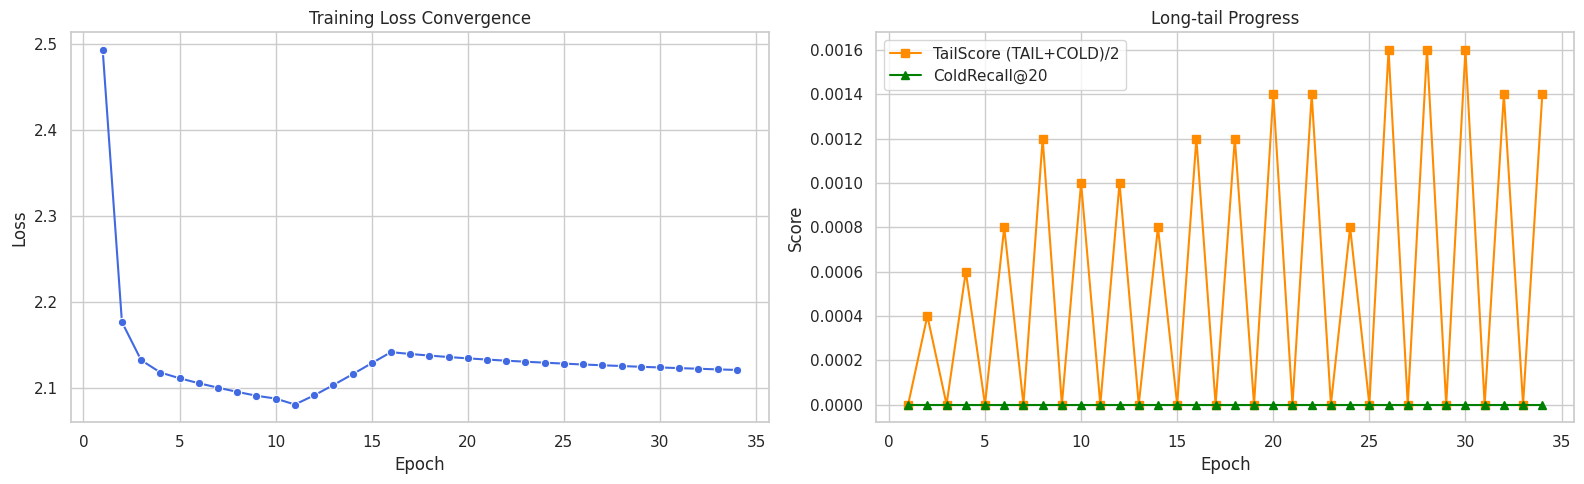

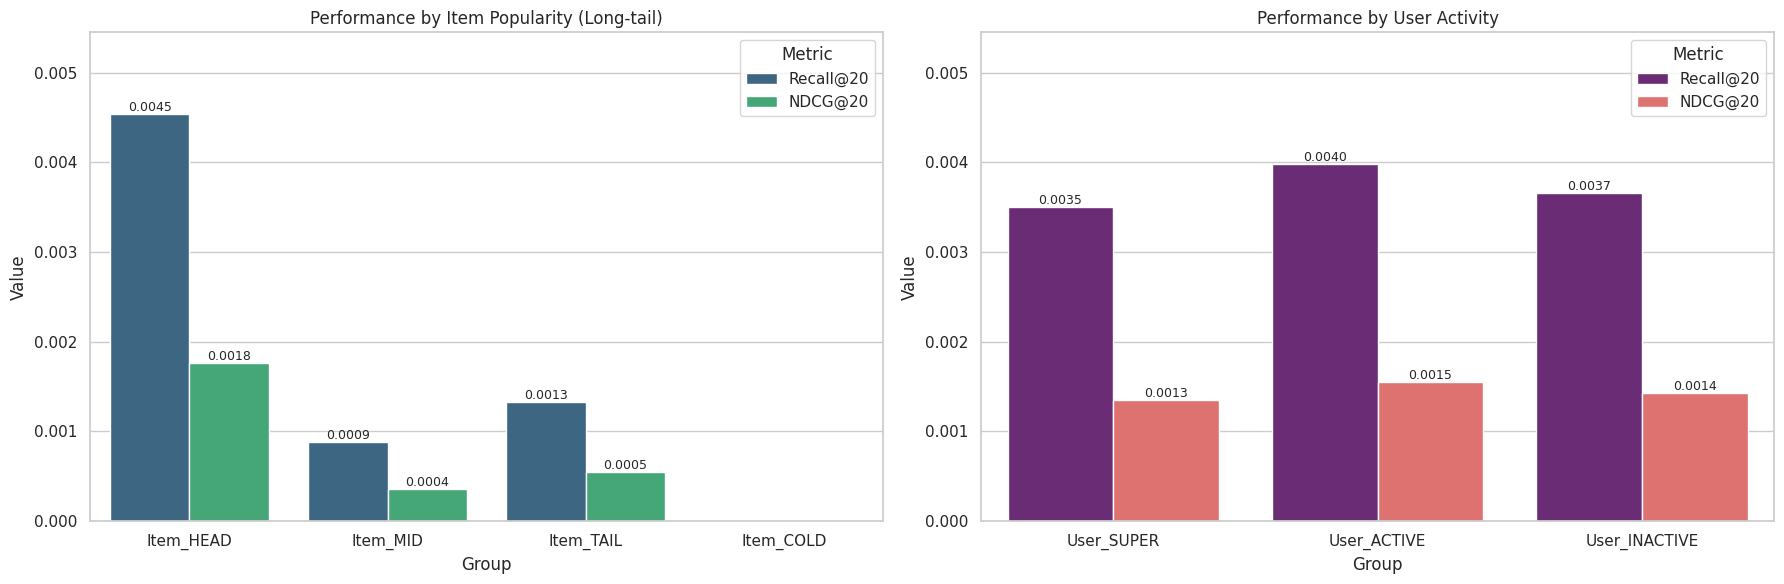

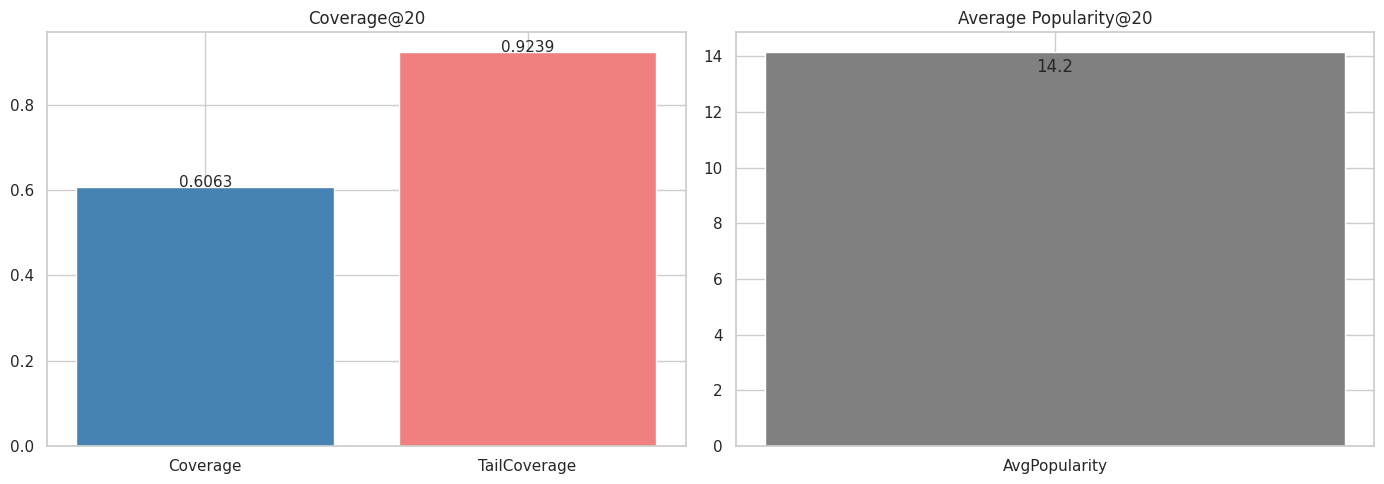

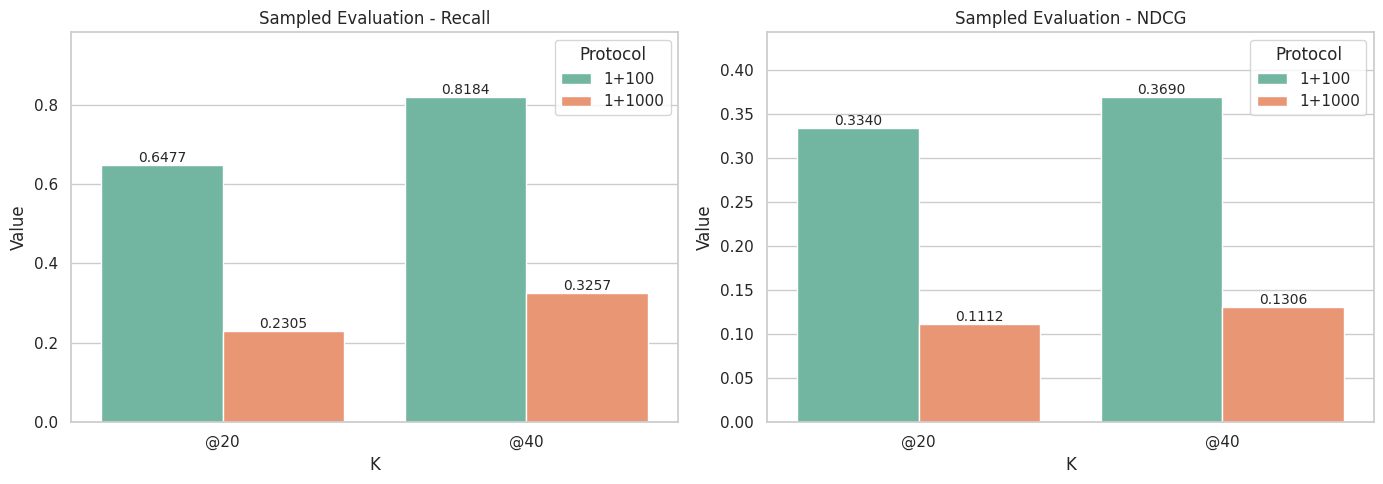

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18 (ĐÃ SỬA): VISUALIZATION – ĐẦY ĐỦ LONG-TAIL PHÂN TÍCH
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['font.size'] = 12

# ── 1. Training History ──────────────────────────────────────────────────────────────
if "history" in globals() and history:
    epochs = [h['epoch'] for h in history]
    loss    = [h.get('loss', 0) for h in history]
    tail_score_hist = [h.get('TailScore', 0) for h in history]
    cold_recall_hist = [h.get('ColdRecall@K', 0) for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(x=epochs, y=loss, ax=ax1, marker='o', color='royalblue')
    ax1.set_title("Training Loss Convergence")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

    ax2.plot(epochs, tail_score_hist, 's-', color='darkorange', label='TailScore (TAIL+COLD)/2')
    ax2.plot(epochs, cold_recall_hist, '^-', color='green', label='ColdRecall@20')
    ax2.set_title("Long‑tail Progress")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] Chưa có history.")

# ── 2. Full-Ranking Stratified Bar Charts ────────────────────────────────────
if "results_full" in globals():
    plot_data = []
    item_groups = ["Item_HEAD", "Item_MID", "Item_TAIL", "Item_COLD"]
    user_groups = ["User_SUPER", "User_ACTIVE", "User_INACTIVE"]
    K = 20  # dùng K=20 cho biểu đồ

    for g in item_groups + user_groups:
        if g in results_full:
            n = results_full[g][K]["n"]
            rec = results_full[g][K]["hits"] / max(n, 1)
            ndcg = results_full[g][K]["ndcg"] / max(n, 1)
            plot_data.append({"Group": g, "Metric": "Recall@20", "Value": rec})
            plot_data.append({"Group": g, "Metric": "NDCG@20", "Value": ndcg})

    if plot_data:
        df_plot = pd.DataFrame(plot_data)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        sns.barplot(data=df_plot[df_plot['Group'].isin(item_groups)],
                    x='Group', y='Value', hue='Metric', ax=ax1, palette="viridis")
        ax1.set_title("Performance by Item Popularity (Long-tail)")
        ax1.set_ylim(0, max(df_plot['Value'])*1.2)
        for p in ax1.patches:
            if p.get_height() > 0:
                ax1.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)

        sns.barplot(data=df_plot[df_plot['Group'].isin(user_groups)],
                    x='Group', y='Value', hue='Metric', ax=ax2, palette="magma")
        ax2.set_title("Performance by User Activity")
        ax2.set_ylim(0, max(df_plot['Value'])*1.2)
        for p in ax2.patches:
            if p.get_height() > 0:
                ax2.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        plt.show()

    # ── 3. Coverage & AvgPopularity biểu đồ riâng ─────────────────────────────
    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))
    covs = [results_full['Coverage@K'][K], results_full['TailCoverage@K'][K]]
    ax3.bar(['Coverage', 'TailCoverage'], covs, color=['steelblue', 'lightcoral'])
    ax3.set_title(f'Coverage@{K}')
    for i, v in enumerate(covs):
        ax3.text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=11)
    ax4.bar(['AvgPopularity'], [results_full['AvgPopularity@K'][K]], color='gray')
    ax4.set_title(f'Average Popularity@{K}')
    ax4.text(0, results_full['AvgPopularity@K'][K]*0.95, f'{results_full["AvgPopularity@K"][K]:.1f}', ha='center')
    plt.tight_layout()
    plt.show()

else:
    print("[WARN] Chưa có results_full. Chạy Cell 15 trước.")

# ── 4. Sampled Evaluation Comparison (1+100 vs 1+1000) ───────────────────────
if "sampled_results" in globals() and "sampled_results_1000" in globals():
    sampled_data = []
    for protocol, res_dict in [("1+100", sampled_results), ("1+1000", sampled_results_1000)]:
        for K_val in [20, 40]:
            sampled_data.append({"Protocol": protocol, "K": f"@{K_val}", "Metric": "Recall", "Value": res_dict[K_val]["recall"]})
            sampled_data.append({"Protocol": protocol, "K": f"@{K_val}", "Metric": "NDCG", "Value": res_dict[K_val]["ndcg"]})

    if sampled_data:
        df_sampled = pd.DataFrame(sampled_data)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.barplot(data=df_sampled[df_sampled["Metric"] == "Recall"], x="K", y="Value", hue="Protocol", ax=axes[0], palette="Set2")
        axes[0].set_title("Sampled Evaluation - Recall")
        axes[0].set_ylim(0, max(df_sampled[df_sampled["Metric"] == "Recall"]["Value"]) * 1.2)
        for p in axes[0].patches:
            if p.get_height() > 0:
                axes[0].annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', fontsize=10)

        sns.barplot(data=df_sampled[df_sampled["Metric"] == "NDCG"], x="K", y="Value", hue="Protocol", ax=axes[1], palette="Set2")
        axes[1].set_title("Sampled Evaluation - NDCG")
        axes[1].set_ylim(0, max(df_sampled[df_sampled["Metric"] == "NDCG"]["Value"]) * 1.2)
        for p in axes[1].patches:
            if p.get_height() > 0:
                axes[1].annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 19: TỰ NGẮT KẾT NỐI (tiết kiệm Compute Units)
# ═══════════════════════════════════════════════════════════════════════════════
import time

print("Toàn bộ pipeline đã hoàn tất và lưu lên Drive.")
print("Hệ thống sẽ ngắt kết nối sau 10 giây...")
time.sleep(10)

try:
    from google.colab import runtime
    runtime.unassign()
except:
    print("[INFO] Không ở môi trường Colab — bỏ qua ngắt kết nối.")

Toàn bộ pipeline đã hoàn tất và lưu lên Drive.
Hệ thống sẽ ngắt kết nối sau 10 giây...
